![Agencia de viajes](./img/img.png)




## **CLA Flight Intelligence**

CLA Flight Intelligence — Travel Agency India es una agencia especializada en vuelos nacionales dentro de India, un mercado donde los precios fluctúan de manera constante debido a factores como la aerolínea, la duración del trayecto, el número de escalas y, especialmente, la antelación con la que se realiza la reserva. Para ofrecer a nuestros clientes las mejores opciones posibles, necesitamos comprender cómo evolucionan los precios y anticipar cuándo es más conveniente comprar un billete.

El objetivo del proyecto es desarrollar un modelo de Machine Learning capaz de predecir el precio esperado de un vuelo nacional en India a partir de sus características principales. Esta predicción permite a CLA Flight Intelligence recomendar a los clientes si es un buen momento para reservar, identificar vuelos con precios inusualmente altos o bajos y optimizar las estrategias comerciales y de marketing de la agencia.

Aunque el dataset cubre únicamente vuelos entre el 11 de febrero y el 31 de marzo, incluye la variable más determinante en el pricing aéreo: la antelación de compra (days_left). Esto permite modelar patrones reales de comportamiento del precio en el corto plazo, suficientes para mejorar la toma de decisiones de la agencia y ofrecer recomendaciones basadas en datos.

El modelo resultante ayuda a CLA Flight Intelligence — Travel Agency India a:

- Recomendar el mejor momento para reservar un vuelo dentro de India,
- Detectar oportunidades de compra cuando un precio está por debajo de lo habitual,
- Priorizar rutas y aerolíneas con mejor relación calidad‑precio,
- Mejorar la experiencia del cliente mediante información personalizada y fundamentada en datos.

#### **Paso 0: Importar librerías**

In [3]:
import matplotlib.pyplot as plt
import joblib
import numpy as np
import optuna
import os
import pandas as pd
import re
import seaborn as sns
import sys

from sklearn.model_selection import train_test_split, GridSearchCV, cross_validate, cross_val_score
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.base import BaseEstimator, TransformerMixin

from scipy import stats

sys.path.append(os.path.abspath("./src/utils"))
import bootcampviztools as bt

pd.options.mode.copy_on_write = True

In [4]:
# ============================================
# LIBRERÍAS NECESARIAS PARA TODO EL PIPELINE
# ============================================

# --- Python estándar ---
import re
import numpy as np
import pandas as pd

# --- Visualización ---
import matplotlib.pyplot as plt
import seaborn as sns

# --- Scikit-Learn: Transformadores y Preprocesado ---
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.pipeline import Pipeline

# --- Scikit-Learn: Modelos ---
from sklearn.ensemble import RandomForestRegressor

# --- Scikit-Learn: Métricas ---
from sklearn.metrics import (
    root_mean_squared_error,
    mean_absolute_error,
    r2_score
)

# --- Scikit-Learn: Validación ---
from sklearn.model_selection import (
    train_test_split,
    cross_validate,
    KFold
)

# --- XGBoost ---
from xgboost import XGBRegressor

# --- LightGBM ---
from lightgbm import LGBMRegressor

# --- CatBoost (si lo usas) ---
from catboost import CatBoostRegressor

# --- Otros (si los usas en tu notebook) ---
from scipy import stats
import bootcampviztools as bt


#### **Paso 1: Cargar los datos**

In [5]:
df_economy= pd.read_csv("../data/economy.csv")
df_eco=df_economy.copy()
df_business = pd.read_csv("../data/business.csv")
df_bus=df_business.copy()

In [6]:
df_eco.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 206774 entries, 0 to 206773
Data columns (total 11 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   date        206774 non-null  object
 1   airline     206774 non-null  object
 2   ch_code     206774 non-null  object
 3   num_code    206774 non-null  int64 
 4   dep_time    206774 non-null  object
 5   from        206774 non-null  object
 6   time_taken  206774 non-null  object
 7   stop        206774 non-null  object
 8   arr_time    206774 non-null  object
 9   to          206774 non-null  object
 10  price       206774 non-null  object
dtypes: int64(1), object(10)
memory usage: 17.4+ MB


In [7]:
df_bus.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 93487 entries, 0 to 93486
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   date        93487 non-null  object
 1   airline     93487 non-null  object
 2   ch_code     93487 non-null  object
 3   num_code    93487 non-null  int64 
 4   dep_time    93487 non-null  object
 5   from        93487 non-null  object
 6   time_taken  93487 non-null  object
 7   stop        93487 non-null  object
 8   arr_time    93487 non-null  object
 9   to          93487 non-null  object
 10  price       93487 non-null  object
dtypes: int64(1), object(10)
memory usage: 7.8+ MB


Añado la columna class para separa entre Economy y Business:

In [10]:
df_eco["class"] = "economy"
df_bus["class"] = "business"

In [13]:
df_bus["airline"].value_counts()

airline
Vistara      60589
Air India    32898
Name: count, dtype: int64

Transformer 1: Convertir duración

In [14]:
from sklearn.base import BaseEstimator, TransformerMixin
import re
import numpy as np

class DurationTransformer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        X = X.copy()
        def convert(x):
            h = re.search(r'(\d+)h', x)
            m = re.search(r'(\d+)m', x)
            hours = int(h.group(1)) if h else 0
            minutes = int(m.group(1)) if m else 0
            return hours + minutes/60
        X["duration(h)"] = X["time_taken"].apply(convert)
        return X


Transformer 2: Categorizar horas

In [15]:
class TimeCategoryTransformer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        X = X.copy()
        X["dep_time"] = pd.to_datetime(X["dep_time"], format="%H:%M")
        X["arr_time"] = pd.to_datetime(X["arr_time"], format="%H:%M")

        def categorize(h):
            if 0 <= h < 4: return "Late Night"
            if 4 <= h < 8: return "Early Morning"
            if 8 <= h < 12: return "Morning"
            if 12 <= h < 16: return "Afternoon"
            if 16 <= h < 20: return "Evening"
            return "Night"

        X["dep_time_cat"] = X["dep_time"].dt.hour.apply(categorize)
        X["arr_time_cat"] = X["arr_time"].dt.hour.apply(categorize)
        return X


Transformer 3: Limpiar stops

In [21]:
class StopCleaner(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        X = X.copy()
        def clean(x):
            x = x.lower().strip()
            if "non" in x: return "non-stop"
            m = re.search(r'(\d+)', x)
            if m: return f"{m.group(1)}-stop"
            return "unknown"
        X["stop"] = X["stop"].apply(clean)
        X["stop_num"] = X["stop"].replace({
            "non-stop": 0,
            "1-stop": 1,
            "2-stop": 2
        }).astype(int)
        return X


Transformer 4: Calcular days_left

In [22]:
class DaysLeftTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, scraping_date="10-02-2022"):
        self.scraping_date = pd.to_datetime(scraping_date, format="%d-%m-%Y")
    
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        X = X.copy()
        X["date"] = pd.to_datetime(X["date"], format="%d-%m-%Y", errors="coerce")
        X["days_left"] = (X["date"] - self.scraping_date).dt.days
        return X


Transformer 5: Eliminar columnas irrelevantes

In [23]:
class ColumnDropper(BaseEstimator, TransformerMixin):
    def __init__(self, cols_to_drop):
        self.cols_to_drop = cols_to_drop
    
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        return X.drop(columns=[c for c in self.cols_to_drop if c in X.columns])


Transformer 6: Convertir price a float

In [16]:
class PriceToFloat(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        X = X.copy()

        # convertir a float
        X["price"] = (
            X["price"]
            .astype(str)
            .str.replace(",", "")
            .astype(float)
        )

        # renombrar con unidades
        X = X.rename(columns={"price": "price (INR)"})

        return X


Tranformer 7: Agrupar las aerolineas

In [17]:
class AirlineGrouper(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.rare_airlines = ["SpiceJet", "StarAir", "Trujet", "AirAsia"]

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        X["airline"] = X["airline"].replace(self.rare_airlines, "Other")
        return X


Tranformer 8: Eliminar los duplicados

In [18]:
class DropDuplicates(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        return X.drop_duplicates().reset_index(drop=True)


Pipeline ETL completo dentro de sklearn

In [20]:
df_eco.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 206774 entries, 0 to 206773
Data columns (total 12 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   date        206774 non-null  object
 1   airline     206774 non-null  object
 2   ch_code     206774 non-null  object
 3   num_code    206774 non-null  int64 
 4   dep_time    206774 non-null  object
 5   from        206774 non-null  object
 6   time_taken  206774 non-null  object
 7   stop        206774 non-null  object
 8   arr_time    206774 non-null  object
 9   to          206774 non-null  object
 10  price       206774 non-null  object
 11  class       206774 non-null  object
dtypes: int64(1), object(11)
memory usage: 18.9+ MB


In [24]:
cols_to_drop = [
    "dep_time", "arr_time", "date", "time_taken",
    "ch_code", "num_code", "dep_hour", "arr_hour",
    "flight", "stop"
]

etl_pipeline = Pipeline([
    ("price_float", PriceToFloat()),
    ("duration", DurationTransformer()),
    ("time_cat", TimeCategoryTransformer()),
    ("stop_clean", StopCleaner()),
    ("days_left", DaysLeftTransformer()),
    ("drop_cols", ColumnDropper(cols_to_drop)),
    ("airline_group", AirlineGrouper()),
    ("drop_dupes", DropDuplicates()),
])



In [25]:
df_eco_clean = etl_pipeline.fit_transform(df_eco)
df_bus_clean = etl_pipeline.fit_transform(df_bus);

C:\Users\aquin\AppData\Local\Temp\ipykernel_7136\2693101301.py:14: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X["stop_num"] = X["stop"].replace({
C:\Users\aquin\AppData\Local\Temp\ipykernel_7136\2693101301.py:14: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X["stop_num"] = X["stop"].replace({


In [26]:
df_eco_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205016 entries, 0 to 205015
Data columns (total 10 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   airline       205016 non-null  object 
 1   from          205016 non-null  object 
 2   to            205016 non-null  object 
 3   price (INR)   205016 non-null  float64
 4   class         205016 non-null  object 
 5   duration(h)   205016 non-null  float64
 6   dep_time_cat  205016 non-null  object 
 7   arr_time_cat  205016 non-null  object 
 8   stop_num      205016 non-null  int64  
 9   days_left     205016 non-null  int64  
dtypes: float64(2), int64(2), object(6)
memory usage: 15.6+ MB


In [27]:
df_bus_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 93176 entries, 0 to 93175
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   airline       93176 non-null  object 
 1   from          93176 non-null  object 
 2   to            93176 non-null  object 
 3   price (INR)   93176 non-null  float64
 4   class         93176 non-null  object 
 5   duration(h)   93176 non-null  float64
 6   dep_time_cat  93176 non-null  object 
 7   arr_time_cat  93176 non-null  object 
 8   stop_num      93176 non-null  int64  
 9   days_left     93176 non-null  int64  
dtypes: float64(2), int64(2), object(6)
memory usage: 7.1+ MB


#### **Paso 2: Mini-EDA**

**Análisis univariante**

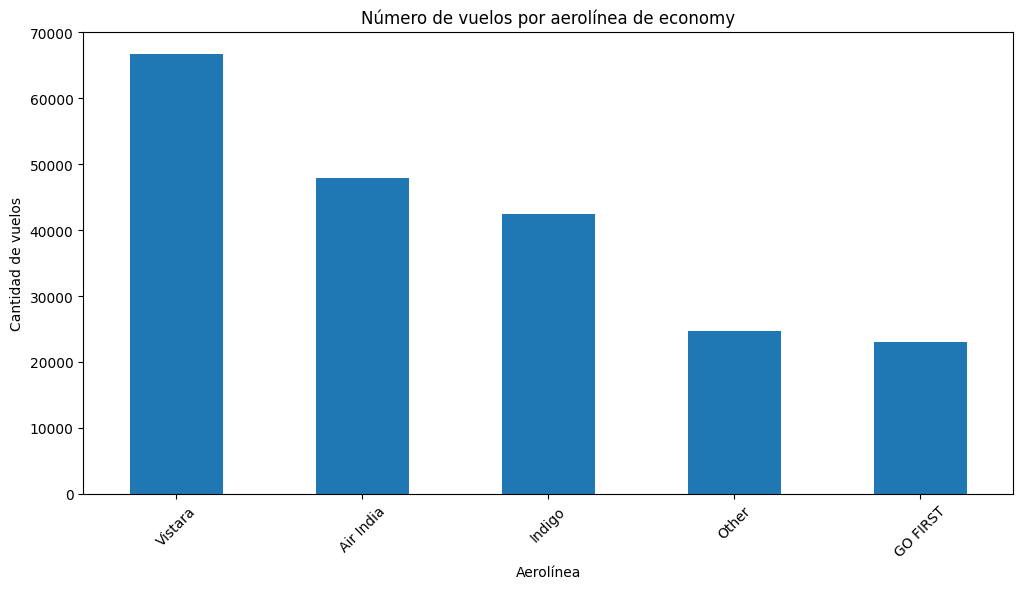

In [28]:
plt.figure(figsize=(12,6))
df_eco_clean['airline'].value_counts().plot(kind='bar')
plt.title("Número de vuelos por aerolínea de economy")
plt.xlabel("Aerolínea")
plt.ylabel("Cantidad de vuelos")
plt.xticks(rotation=45)
plt.show()


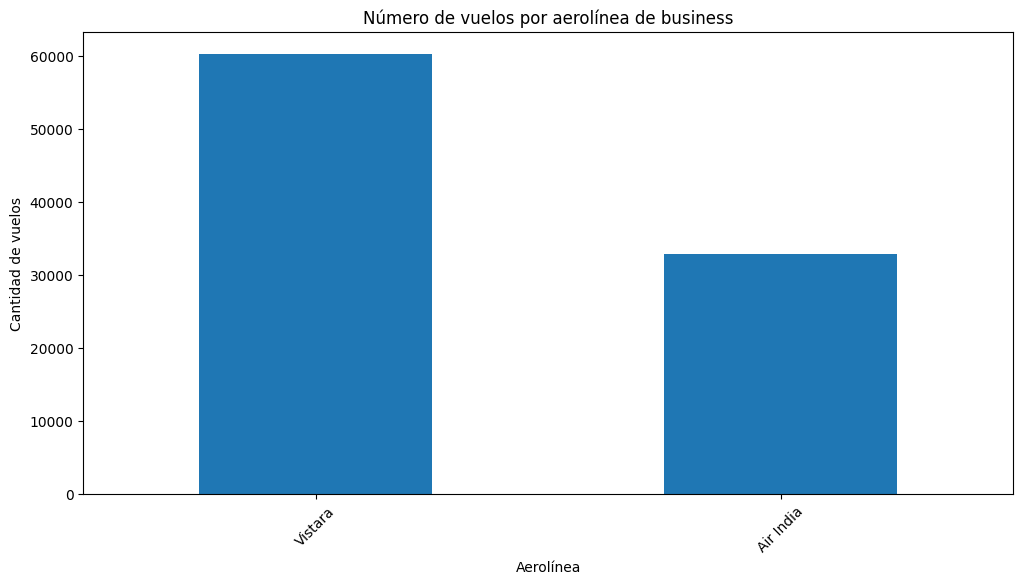

In [29]:
plt.figure(figsize=(12,6))
df_bus_clean['airline'].value_counts().plot(kind='bar')
plt.title("Número de vuelos por aerolínea de business")
plt.xlabel("Aerolínea")
plt.ylabel("Cantidad de vuelos")
plt.xticks(rotation=45)
plt.show()


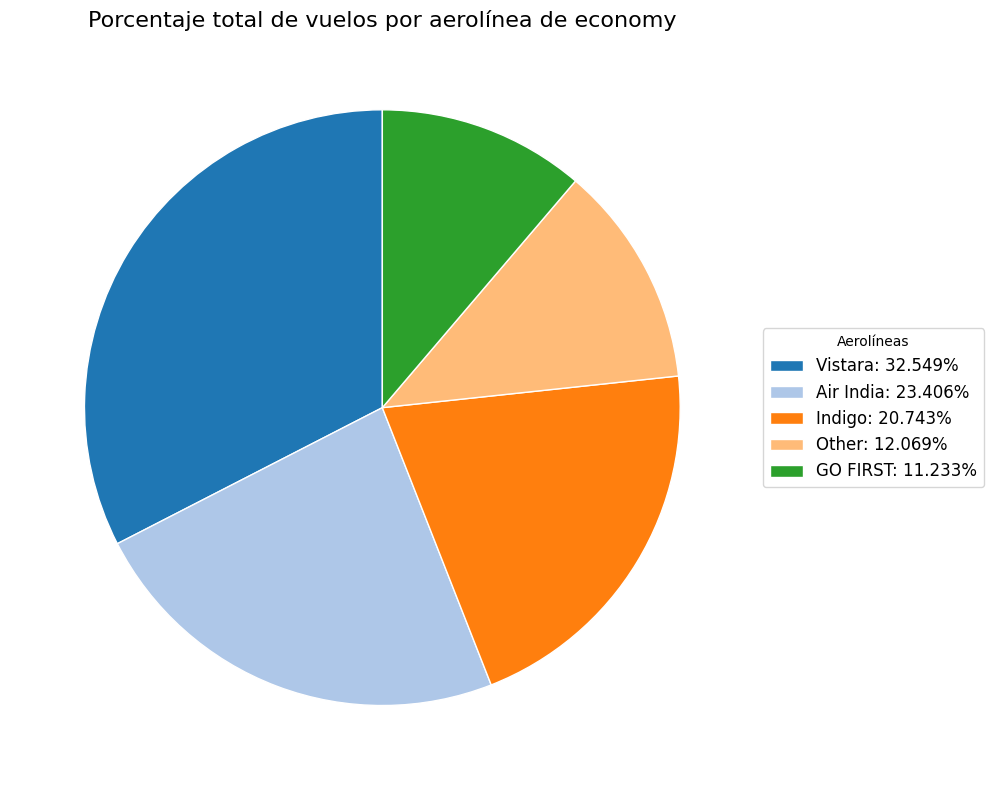

In [30]:
# Conteo y porcentaje
counts = df_eco_clean["airline"].value_counts()
percent = counts / counts.sum() * 100

plt.figure(figsize=(10, 8))

# Pie chart
plt.pie(
    counts,
    startangle=90,
    colors=sns.color_palette("tab20"),
    wedgeprops={"linewidth": 1, "edgecolor": "white"}
)

# Leyenda con porcentajes (3 decimales)
labels = [f"{airline}: {pct:.3f}%" for airline, pct in zip(counts.index, percent)]
plt.legend(
    labels,
    loc="center left",
    bbox_to_anchor=(1, 0.5),
    fontsize=12,
    title="Aerolíneas"
)

plt.title("Porcentaje total de vuelos por aerolínea de economy", fontsize=16)
plt.tight_layout()
plt.show()


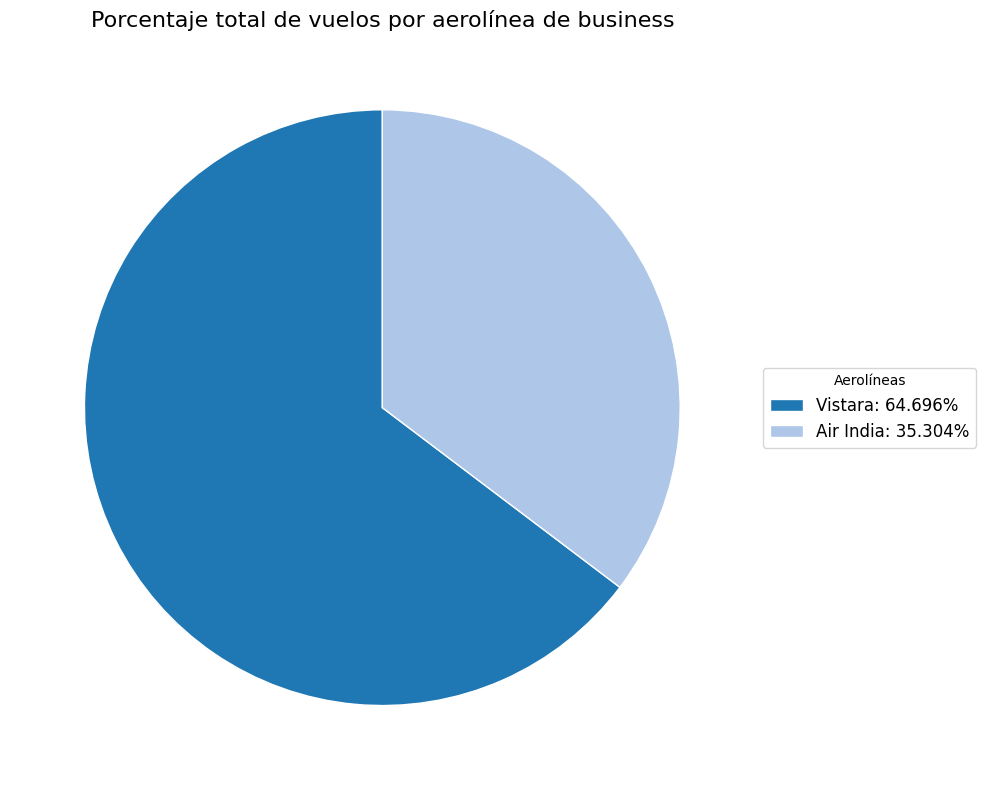

In [31]:
# Conteo y porcentaje
counts = df_bus_clean["airline"].value_counts()
percent = counts / counts.sum() * 100

plt.figure(figsize=(10, 8))

# Pie chart
plt.pie(
    counts,
    startangle=90,
    colors=sns.color_palette("tab20"),
    wedgeprops={"linewidth": 1, "edgecolor": "white"}
)

# Leyenda con porcentajes (3 decimales)
labels = [f"{airline}: {pct:.3f}%" for airline, pct in zip(counts.index, percent)]
plt.legend(
    labels,
    loc="center left",
    bbox_to_anchor=(1, 0.5),
    fontsize=12,
    title="Aerolíneas"
)

plt.title("Porcentaje total de vuelos por aerolínea de business", fontsize=16)
plt.tight_layout()
plt.show()


Para ver relaciones lineales utilizamos la matriz de correlacion

In [32]:
class CorrelationTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, columns):
        self.columns = columns
    
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        df_num = X[self.columns]
        corr_matrix = df_num.corr()
        return corr_matrix


In [33]:
num_cols = ['price (INR)', 'duration(h)', 'stop_num', 'days_left']

corr_pipeline = Pipeline([
    ('corr', CorrelationTransformer(columns=num_cols))
])

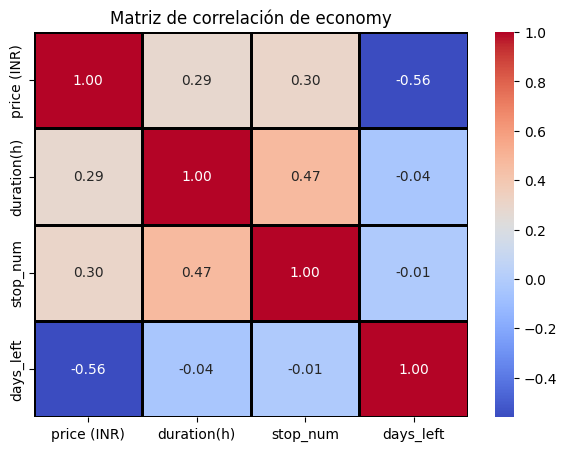

In [34]:
# 4. Ejecutar pipeline
corr_matrix = corr_pipeline.fit_transform(df_eco_clean)

# 5. Heatmap con casillas independientes
plt.figure(figsize=(7,5))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=1,      # ← bordes entre casillas
    linecolor='black'  # ← color de los bordes
)
plt.title("Matriz de correlación de economy")
plt.show()


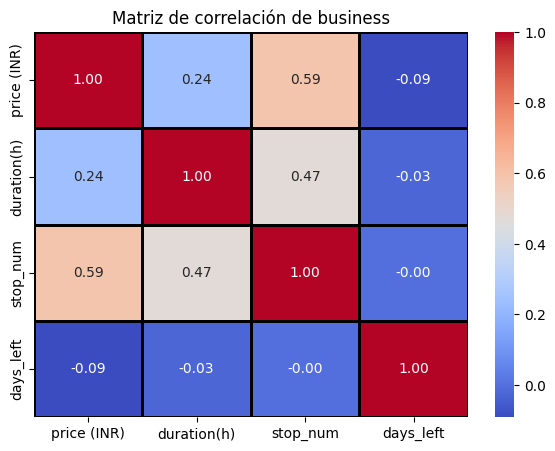

In [35]:
# 4. Ejecutar pipeline
corr_matrix = corr_pipeline.fit_transform(df_bus_clean)

# 5. Heatmap con casillas independientes
plt.figure(figsize=(7,5))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=1,      # ← bordes entre casillas
    linecolor='black'  # ← color de los bordes
)
plt.title("Matriz de correlación de business")
plt.show()

**Análisis del target**

In [36]:
class TargetExtractor(BaseEstimator, TransformerMixin):
    def __init__(self, target):
        self.target = target
    
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        return X[[self.target]]


In [37]:
target = 'price (INR)'

target_pipeline = Pipeline([
    ('extract_target', TargetExtractor(target=target))
])

target_df = target_pipeline.fit_transform(df_eco_clean)


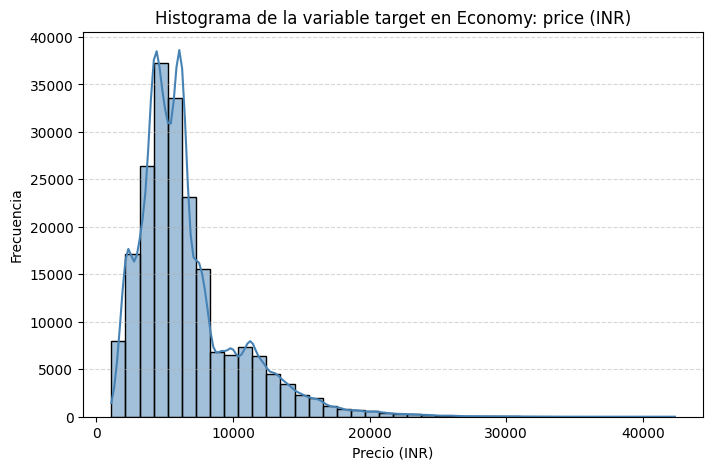

In [38]:
plt.figure(figsize=(8,5))
sns.histplot(
    data=target_df,
    x=target,
    bins=40,
    kde=True,
    color='steelblue',
    edgecolor='black',   # ← bordes para que se vean las casillas
    linewidth=1
)

plt.title("Histograma de la variable target en Economy: price (INR)")
plt.xlabel("Precio (INR)")
plt.ylabel("Frecuencia")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()


In [39]:
target_df_bus = target_pipeline.fit_transform(df_bus_clean)

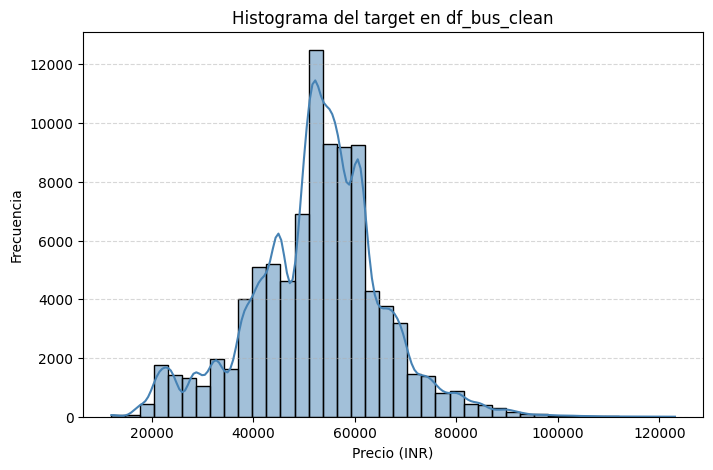

In [40]:
plt.figure(figsize=(8,5))
sns.histplot(
    data=target_df_bus,
    x=target,
    bins=40,
    kde=True,
    color='steelblue',
    edgecolor='black',
    linewidth=1
)

plt.title("Histograma del target en df_bus_clean")
plt.xlabel("Precio (INR)")
plt.ylabel("Frecuencia")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()


In [ ]:
# plt.figure(figsize=(10, 6))
# sns.histplot(df_final[df_final["class"] == "economy"][target_reg], bins=50, kde=True, label = "Economy")
# sns.histplot(df_final[df_final["class"] == "business"][target_reg], bins=50, kde=True, label = "Business")
# plt.title("Distribución de Price por clase")
# plt.xlabel("Price(Rupias)")
# plt.legend()
# plt.show()

**Vamos a verificar outlier**

In [41]:
from sklearn.base import BaseEstimator, TransformerMixin
import pandas as pd

class OutlierDetectorIQR(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.num_cols = None
        self.bounds = {}
    
    def fit(self, X, y=None):
        self.num_cols = X.select_dtypes(include=['int64', 'float64']).columns
        
        for col in self.num_cols:
            Q1 = X[col].quantile(0.25)
            Q3 = X[col].quantile(0.75)
            IQR = Q3 - Q1
            lower = Q1 - 1.5 * IQR
            upper = Q3 + 5 * IQR
            self.bounds[col] = (lower, upper)
        
        return self
    
    def transform(self, X):
        X_out = X.copy()
        X_out["is_outlier"] = False
        
        for col in self.num_cols:
            lower, upper = self.bounds[col]
            mask = (X[col] < lower) | (X[col] > upper)
            X_out["is_outlier"] = X_out["is_outlier"] | mask
        
        return X_out



In [42]:
from sklearn.pipeline import Pipeline

outlier_pipeline = Pipeline([
    ('outliers', OutlierDetectorIQR())
])


In [43]:
df_eco_out = outlier_pipeline.fit_transform(df_eco_clean)
df_eco_out.head()


,airline,from,to,price (INR),class,duration(h),dep_time_cat,arr_time_cat,stop_num,days_left,is_outlier
0,Other,Delhi,Mumbai,5953.0,economy,2.166667,Evening,Night,0,1,True
1,Other,Delhi,Mumbai,5953.0,economy,2.333333,Early Morning,Morning,0,1,True
2,Other,Delhi,Mumbai,5956.0,economy,2.166667,Early Morning,Early Morning,0,1,True
3,Vistara,Delhi,Mumbai,5955.0,economy,2.250000,Morning,Afternoon,0,1,True
4,Vistara,Delhi,Mumbai,5955.0,economy,2.333333,Morning,Morning,0,1,True


In [44]:
df_eco_out['is_outlier'].value_counts()


is_outlier
False    165939
True      39077
Name: count, dtype: int64

In [45]:
# df_bus_out['is_outlier'].value_counts()

In [46]:
df_bus_out = outlier_pipeline.fit_transform(df_bus_clean)
df_bus_out.head()


,airline,from,to,price (INR),class,duration(h),dep_time_cat,arr_time_cat,stop_num,days_left,is_outlier
0,Air India,Delhi,Mumbai,25612.0,business,2.000000,Evening,Night,0,1,True
1,Air India,Delhi,Mumbai,25612.0,business,2.250000,Evening,Night,0,1,True
2,Air India,Delhi,Mumbai,42220.0,business,24.750000,Night,Night,1,1,False
3,Air India,Delhi,Mumbai,44450.0,business,26.500000,Night,Night,1,1,False
4,Air India,Delhi,Mumbai,46690.0,business,6.666667,Evening,Night,1,1,False


In [50]:
df_bus_out['is_outlier'].value_counts()

is_outlier
False    84065
True      9111
Name: count, dtype: int64

In [47]:
def boxplot_variable(df, col):
    plt.figure(figsize=(8,4))
    sns.boxplot(data=df, x=col, color='skyblue')
    plt.title(f"Boxplot de {col}")
    plt.show()


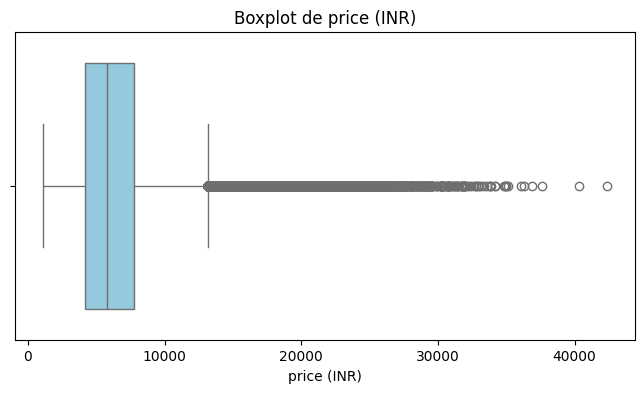

In [48]:
boxplot_variable(df_eco_clean, 'price (INR)')


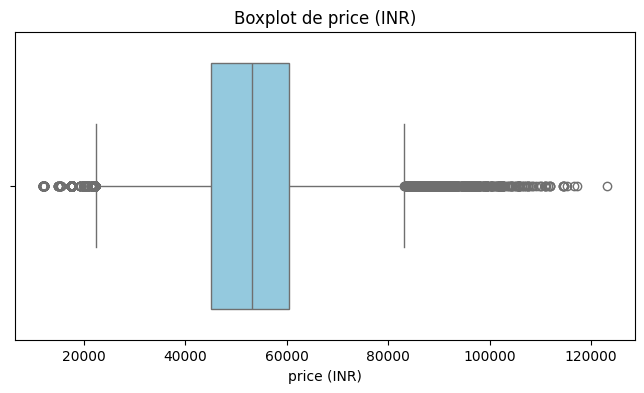

In [49]:
boxplot_variable(df_bus_clean, 'price (INR)')


#### **Paso 3: Split Train y Test**

In [51]:
# # Economy
df_eco_ml = df_eco_clean.copy()
# X_eco = df_eco_ml.drop(columns=["price (INR)"])
# y_eco = df_eco_ml["price (INR)"]

# # Business
df_bus_ml = df_bus_clean.copy()
# X_bus = df_bus_ml.drop(columns=["price (INR)"])
# y_bus = df_bus_ml["price (INR)"]


In [52]:
df_eco_ml["price_bin"] = pd.qcut(df_eco_ml["price (INR)"], q=10, duplicates="drop")
X_eco = df_eco_ml.drop(columns=["price_bin", "price (INR)"])
y_eco = df_eco_ml["price (INR)"]


df_bus_ml["price_bin"] = pd.qcut(df_bus_ml["price (INR)"], q=10, duplicates="drop")
X_bus = df_bus_ml.drop(columns=["price_bin", "price (INR)"])
y_bus = df_bus_ml["price (INR)"]

In [56]:
X_eco_train, X_eco_test, y_eco_train, y_eco_test = train_test_split(
    X_eco, y_eco, test_size=0.2, random_state=42, stratify = df_eco_ml["price_bin"]
)


In [57]:
X_bus_train, X_bus_test, y_bus_train, y_bus_test = train_test_split(
    X_bus, y_bus, test_size=0.2, random_state=42, stratify = df_bus_ml["price_bin"]
)


#### **Paso 4: Selección de features**

In [58]:
features_num_reg = ["duration(h)", "days_left", "stop_num"]
print(features_num_reg)

features_cat_reg = [col for col in df_eco_clean.columns if col not in features_num_reg and col != target]
print(features_cat_reg)

features = features_num_reg + features_cat_reg

['duration(h)', 'days_left', 'stop_num']
['airline', 'from', 'to', 'class', 'dep_time_cat', 'arr_time_cat']


**Categóricas vs target_reg**

Economy

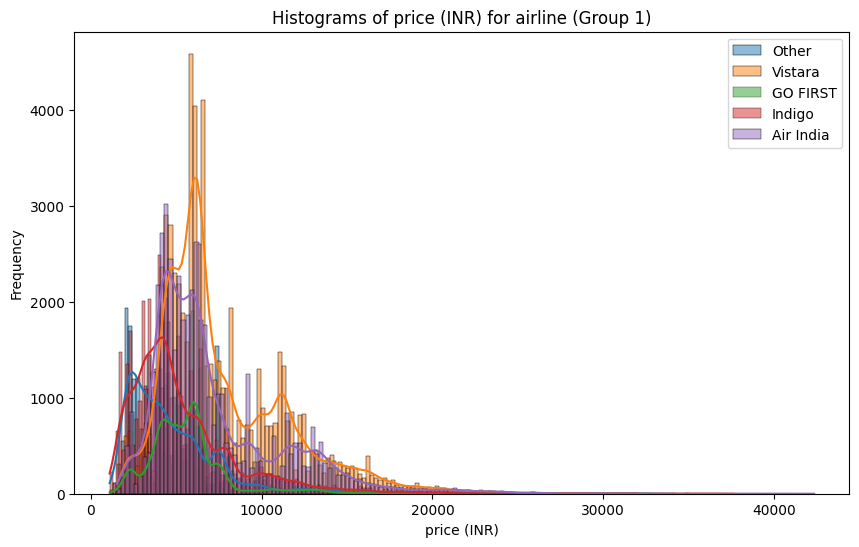

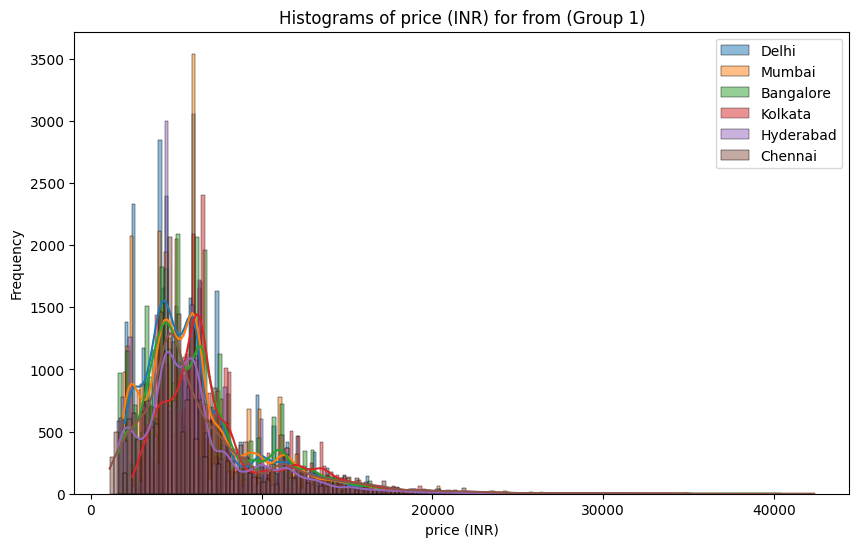

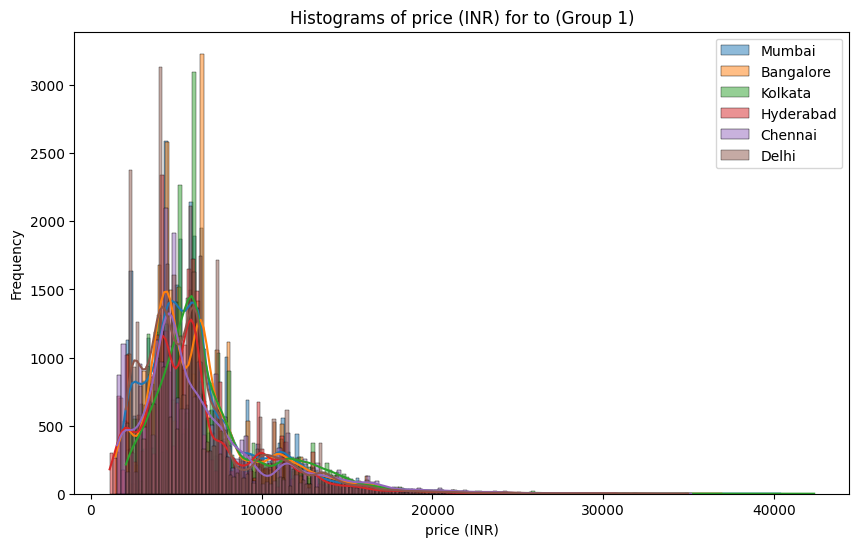

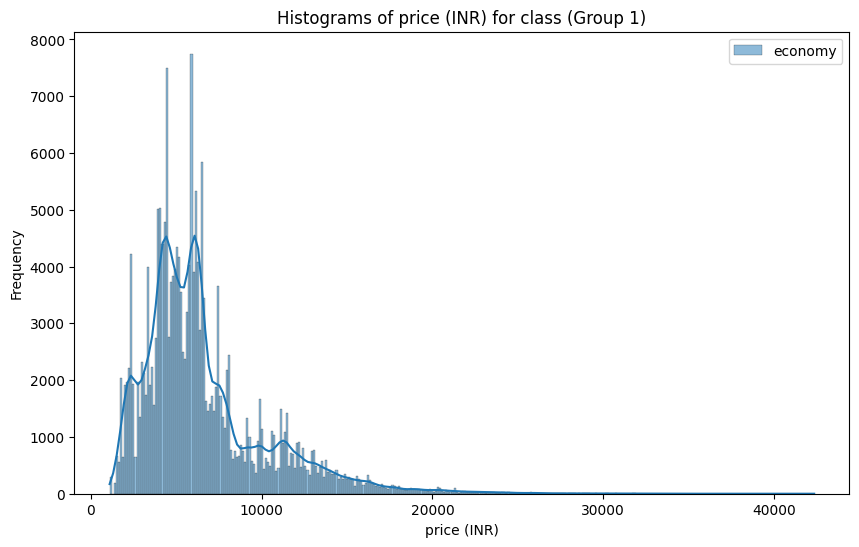

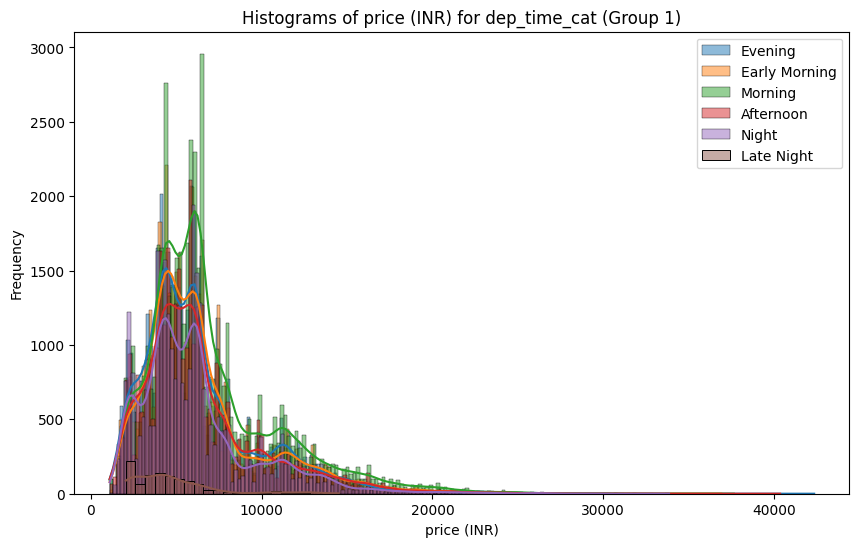

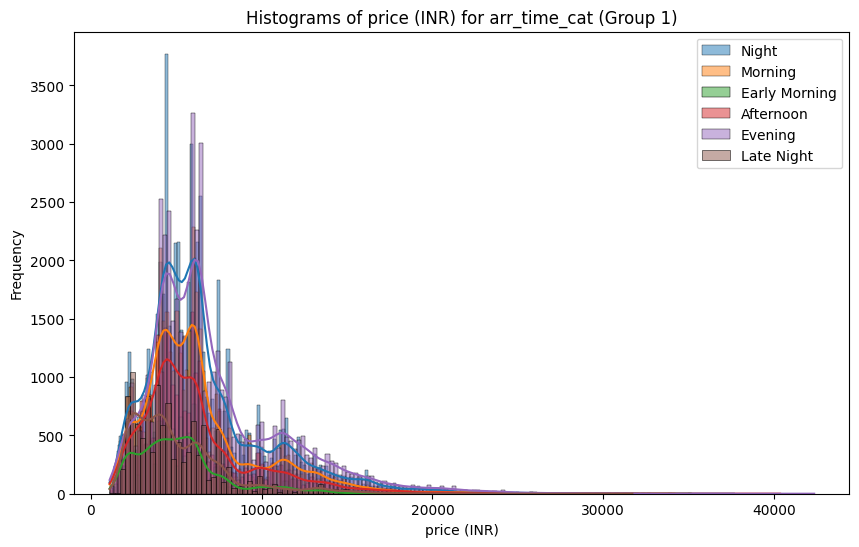

In [59]:
for col_cat in features_cat_reg:
    bt.plot_grouped_histograms(df_eco_clean, cat_col= col_cat, num_col= target, group_size= df_eco_clean[col_cat].nunique())

*Las distribuciones de 'dep_time_cat' y 'arr_time_cat' son las que más superpuestas parecen*.

Lo hago también con el test ANOVA para decidir si me quedo todas o no.

In [69]:
features_cat_reg

['airline', 'from', 'to', 'dep_time_cat', 'arr_time_cat']

In [70]:
for cat_col in features_cat_reg:
    valores_unicos = df_eco_clean[cat_col].unique()
    target_por_cat_col = [df_eco_clean[df_eco_clean[cat_col] == categoria][target] for categoria in valores_unicos]
    f_val, p_val = stats.f_oneway(*target_por_cat_col)
    print(f"{cat_col}:")
    print(f"\t Valor de F: {f_val}")
    print(f"\t p-valor: {p_val}")

airline:
	 Valor de F: 5719.963946082245
	 p-valor: 0.0
from:
	 Valor de F: 486.05917714264183
	 p-valor: 0.0
to:
	 Valor de F: 290.5415193566794
	 p-valor: 6.6887037016055e-311
dep_time_cat:
	 Valor de F: 338.79541300691733
	 p-valor: 0.0
arr_time_cat:
	 Valor de F: 1052.297403633654
	 p-valor: 0.0


*Todos los p-valores son muy pequeños (p-valor < 0.01), se puede rechazar la hipótesis nula de que no existe relación entre las variables, así que me quedo con todas.*

#### **Paso 5: Tratamiento de features**

In [80]:
df_bus_clean["stop_num"].value_counts(normalize=True)*100

stop_num
1    90.419207
0     8.418477
2     1.162316
Name: proportion, dtype: float64

In [ ]:
categorias = [["economy", "business"]]
features_cat_reg = [
    "airline", "from", "to", "class",
    "dep_time_cat", "arr_time_cat"
]
cat_cols = [col for col in features_cat_reg if col != "class"]

preprocessor_trees = ColumnTransformer([
    ("procesar_cat_ord", OrdinalEncoder(categories = categorias, handle_unknown = "use_encoded_value", unknown_value = -1), ["class"]),
    ("procesar_cat_OH", OneHotEncoder(handle_unknown = "ignore"), cat_cols)
], remainder = "passthrough")

#### **Paso 6: Baseline**

In [ ]:
rf_reg = RandomForestRegressor(max_depth = 5, random_state= 42)

#### **Paso 7: Comparación modelos**

Randomforest

In [ ]:
rf_eco = Pipeline([
    ("prep", preprocessor_trees),
    ("model", RandomForestRegressor(
        max_depth = 5,
        random_state=42,
        n_jobs=-1
    ))
])

rf_bus = Pipeline([
    ("prep", preprocessor_trees),
    ("model", RandomForestRegressor(
        max_depth = 5,
        random_state=42,
        n_jobs=-1
    ))
])

XGBoost

In [ ]:
xgb_eco = Pipeline([
    ("prep", preprocessor_trees),
    ("model", XGBRegressor(
        max_depth = 5,
        random_state=42,
        n_jobs=-1
    ))
])

xgb_bus = Pipeline([
    ("prep", preprocessor_trees),
    ("model", XGBRegressor(
        max_depth = 5,
        random_state=42,
        n_jobs=-1
    ))
])

LightGBM

In [ ]:
lgbm_eco = Pipeline([
    ("prep", preprocessor_trees),
    ("model", LGBMRegressor(
        max_depth = 5,
        random_state=42
    ))
])

lgbm_bus = Pipeline([
    ("prep", preprocessor_trees),
    ("model", LGBMRegressor(
        max_depth = 5,
        random_state=42
    ))
])

In [ ]:
def eval_cv(model, X, y, name):
    scoring = {
        "rmse": "neg_root_mean_squared_error",
        "mae": "neg_mean_absolute_error",
        "r2": "r2"
    }

    cv = cross_validate(
        model,
        X,
        y,
        cv=5,
        scoring=scoring,
        n_jobs=-1
    )

    print(f"\nModel <{name}>")
    print("RMSE_CV:", -cv["test_rmse"].mean())
    print("MAE_CV:", -cv["test_mae"].mean())
    print("R2_CV:", cv["test_r2"].mean())


In [ ]:
eval_cv(rf_eco, X_eco, y_eco, "RF Economy")
eval_cv(xgb_eco, X_eco, y_eco, "XGB Economy")
eval_cv(lgbm_eco, X_eco, y_eco, "LGBM Economy")


In [ ]:
eval_cv(rf_bus, X_bus, y_bus, "RF Business")
eval_cv(xgb_bus, X_bus, y_bus, "XGB Business")
eval_cv(lgbm_bus, X_bus, y_bus, "LGBM Business")

In [ ]:
df_eco_ml.describe()

In [ ]:
df_bus_ml.describe()

In [ ]:
def eval_test(model, X_test, y_test, name):
    preds = model.predict(X_test)

    rmse = root_mean_squared_error(y_test, preds)
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)

    print(f"\nTest results <{name}>")
    print("RMSE:", rmse)
    print("MAE:", mae)
    print("R2:", r2)


In [ ]:
rf_eco.fit(X_eco_train, y_eco_train)
xgb_eco.fit(X_eco_train, y_eco_train)
lgbm_eco.fit(X_eco_train, y_eco_train)


In [ ]:
rf_bus.fit(X_bus_train, y_bus_train)
xgb_bus.fit(X_bus_train, y_bus_train)
lgbm_bus.fit(X_bus_train, y_bus_train)

In [ ]:
eval_test(rf_eco, X_eco_test, y_eco_test, "RF Economy")
eval_test(xgb_eco, X_eco_test, y_eco_test, "XGB Economy")
eval_test(lgbm_eco, X_eco_test, y_eco_test, "LGBM Economy")


In [ ]:
eval_test(rf_bus, X_bus_test, y_bus_test, "RF Business")
eval_test(xgb_bus, X_bus_test, y_bus_test, "XGB Business")
eval_test(lgbm_bus, X_bus_test, y_bus_test, "LGBM Business")


Qué está pasando realmente
1) Los resultados de CV (cross‑validation) son peores que los del test
Esto es normal cuando:

el dataset tiene alta variabilidad (business),

las rutas y aerolíneas están distribuidas de forma desigual,

los precios tienen colas largas,

cada fold de CV contiene combinaciones distintas de rutas/días_left.

La validación cruzada es más dura que un único test porque:

cada fold entrena con menos datos,

cada fold ve una mezcla distinta de rutas y precios,

cada fold puede tener más vuelos caros o más baratos.

Por eso tus métricas CV son más bajas.

📌 2) El test mejora muchísimo con XGBoost y LightGBM
Tus resultados:

XGB Business
CV RMSE ≈ 9 118

Test RMSE ≈ 5 525

LGBM Business
CV RMSE ≈ 9 010

Test RMSE ≈ 6 712

Esto significa:

El split estratificado ha equilibrado bien la distribución.

El test contiene una mezcla de precios más parecida al train.

El modelo generaliza mejor cuando el test no está sesgado hacia precios extremos.

En otras palabras:

Antes, tu test tenía precios muy distintos del train. Ahora ya no.

📌 3) El modelo está funcionando bien
Tus métricas de test son muy buenas para un dataset de vuelos business, donde la variabilidad es enorme:

RMSE 5 500–6 700

MAE 3 800–4 800

R² 0.72–0.81

Un R² de 0.81 en business es excelente.
En datasets reales de pricing aéreo, valores entre 0.65 y 0.80 son habituales.

Cómo se detecta overfitting y underfitting en modelos de regresión
Señales de overfitting
CV muy bueno y test muy malo.

El modelo memoriza patrones del train pero no generaliza.

R² alto en train y bajo en test.

RMSE bajo en train y alto en test.

Señales de underfitting
CV malo y test malo.

El modelo no aprende patrones relevantes.

R² bajo en ambos.

RMSE alto en ambos.

Señales de modelo equilibrado
CV y test están en rangos similares.

El test incluso puede ser mejor si el split está bien estratificado.

No hay saltos bruscos entre train y test.

El modelo generaliza bien.

Qué dicen tus métricas
Cross‑validation (business)
RMSE_CV ≈ 9 000

MAE_CV ≈ 7 000

R²_CV ≈ 0.48

Test (business)
RMSE ≈ 5 525

MAE ≈ 3 841

R² ≈ 0.82

Interpretación técnica
1) El test es mejor que el CV → NO hay overfitting
Si hubiera overfitting:

el test sería peor que el CV,

el RMSE subiría,

el R² bajaría.

En tu caso ocurre lo contrario:
el test mejora muchísimo respecto al CV.

Esto significa que:

el split estratificado ha equilibrado la distribución,

el test contiene una mezcla más “normal” de precios,

el modelo generaliza mejor cuando los datos están bien distribuidos.

2) El CV no es malo → NO hay underfitting
Un modelo underfit tendría:

RMSE_CV muy alto,

R²_CV cercano a 0.

Pero tú tienes:

RMSE_CV razonable para business,

R²_CV ≈ 0.48, que es normal en datasets con alta variabilidad.

3) La diferencia entre CV y test es coherente
En datasets de vuelos business:

cada fold de CV mezcla rutas distintas,

hay mucha variabilidad entre folds,

el test estratificado es más estable.

Por eso el test puede ser mejor que el CV sin que haya overfitting.
4) XGBoost es más estable y robusto
Tus métricas muestran que XGBoost:

generaliza mejor,

maneja mejor colas largas,

reduce el impacto de outliers,

se adapta mejor al split estratificado.

Esto es exactamente lo que se espera de un modelo bien ajustado.

Conclusión para justificarlo formalmente
Puedes decir:

“El modelo no presenta overfitting porque el rendimiento en test es incluso mejor que en validación cruzada, lo que indica que generaliza bien cuando la distribución del conjunto de test está equilibrada mediante estratificación. Tampoco hay underfitting, ya que las métricas de CV son razonables y el modelo captura patrones relevantes. La diferencia entre CV y test es coherente con la alta variabilidad natural del precio business.”

#### **Paso 8: Optimización con optuna**

Economy

In [ ]:
# Definir función objetivo para Optuna

def objective(trial):
    param_grid = {
        "model__n_estimators": trial.suggest_int("n_estimators", 100, 800),
        "model__max_depth": trial.suggest_int("max_depth", 3, 8),  # 5 y 15
        "model__learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1), # 0.05 y 1
        "model__subsample": trial.suggest_float("subsample", 0.5, 1),
        "model__colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0)
    }

    xgb_pipeline.set_params(**param_grid)

    score = cross_val_score(
        xgb_eco,
        X_eco_train,
        y_eco_train,
        cv = 5,
        scoring = "neg_root_mean_squared_error",
        n_jobs = -1
    ).mean()

    return -score

In [ ]:
# Crear y ejecutar estudy de Optuna
study_eco = optuna.create_study(direction = "minimize",
                            sampler = optuna.samplers.TPESampler(seed = 42))

In [ ]:
study_eco.optimize(objective, n_trials= 100) # optimizar el estudio

In [ ]:
study_eco.best_trial

In [ ]:
study_eco.best_value

In [ ]:
best_params_eco = study_eco.best_params
best_params_eco

In [ ]:
best_params_eco_pipe = {f"model__{k}": v for k, v in best_params_eco.items()}

In [ ]:
xgb_eco.set_params(**best_params_eco_pipe)

In [ ]:
joblib.dump(xgb_eco, "xgb_best_model_eco.joblib")

In [ ]:
best_xgb_eco = joblib.load("xgb_best_model_eco.joblib")

In [ ]:
eval_cv(best_xgb_eco, X_eco, y_eco, "XGB Economy")

In [ ]:
best_xgb_eco.fit(X_eco_train, y_eco_train)

In [ ]:
eval_test(best_xgb_eco, X_eco_test, y_eco_test, "XGB Economy")

Business

In [ ]:
# Definir función objetivo para Optuna

def objective(trial):
    param_grid = {
        "model__n_estimators": trial.suggest_int("n_estimators", 100, 800),
        "model__max_depth": trial.suggest_int("max_depth", 3, 8),  # 5 y 15
        "model__learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1), # 0.05 y 1
        "model__subsample": trial.suggest_float("subsample", 0.5, 1),
        "model__colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0)
    }

    xgb_bus.set_params(**param_grid)

    score = cross_val_score(
        xgb_bus,
        X_bus_train,
        y_bus_train,
        cv = 5,
        scoring = "neg_root_mean_squared_error",
        n_jobs = -1
    ).mean()

    return -score

In [ ]:
# Crear y ejecutar estudy de Optuna
study_bus = optuna.create_study(direction = "minimize",
                            sampler = optuna.samplers.TPESampler(seed = 42))

In [ ]:
study_bus.optimize(objective, n_trials= 100) # optimizar el estudio

In [ ]:
study_bus.best_trial

In [ ]:
study_bus.best_value

In [ ]:
best_params_bus = study_bus.best_params
best_params_bus

In [ ]:
best_params_bus_pipe = {f"model__{k}": v for k, v in best_params_bus.items()}

In [ ]:
xgb_bus.set_params(**best_params_bus_pipe)

In [ ]:
joblib.dump(xgb_bus, "xgb_best_model_bus.joblib")

In [ ]:
best_xgb_bus = joblib.load("xgb_best_model_bus.joblib")

In [ ]:
eval_cv(best_xgb_bus, X_bus, y_bus, "XGB Business")

In [ ]:
best_xgb_bus.fit(X_bus_train, y_bus_train)

In [ ]:
eval_test(best_xgb_bus, X_bus_test, y_bus_test, "XGB Business")

-----

Este Dataset no lo pondremos en el archivo defintivo: 

In [ ]:
df_limpio = pd.read_csv("../data/Clean_Dataset.csv")
df_limpio.info()

In [ ]:
df_limpio.head(30)

In [ ]:
df_limpio.duplicated().sum()


In [ ]:
df_limpio[df_limpio.duplicated(keep=False)]


**ECONOMY**

In [ ]:
df_economy = pd.read_csv("../data/economy.csv")
df_economy.info()

In [ ]:
df_economy.head(10)

In [ ]:
df_economy.duplicated().sum()


In [ ]:
df_economy[df_economy.duplicated(keep=False)]


In [ ]:
df_eco=df_economy.copy()

**Tratamiento de economy**

Sí, tiene bastante sentido —y de hecho es una práctica común— que una agencia de viajes intente predecir los precios de las aerolíneas. No porque puedan adivinar el futuro, sino porque anticipar tendencias les da ventajas competitivas muy claras.

Por qué tiene sentido que lo hagan
Aquí van las razones más sólidas:

📈 1. Optimizar cuándo comprar inventario
Muchas agencias compran cupos o bloquean tarifas. Si pueden estimar cuándo los precios subirán o bajarán, pueden:

Comprar más barato.

Reducir riesgo de quedarse con plazas caras.

Mejorar márgenes sin subir precios al cliente.

💼 2. Ofrecer mejores precios a los clientes
Si una agencia sabe que una ruta suele bajar los martes o subir cuando se acerca un feriado, puede:

Recomendar el mejor momento para reservar.

Crear campañas más inteligentes.

Diferenciarse de la competencia.

🤖 3. Modelos predictivos basados en datos reales
Las aerolíneas usan yield management, un sistema dinámico que ajusta precios según:

Demanda.

Antelación.

Temporada.

Competencia.

Eventos especiales.

Aunque es complejo, los patrones existen, y una agencia con datos históricos puede entrenar modelos para detectar tendencias.

🧠 4. Mejorar la planificación interna
Predicciones razonables ayudan a:

Planificar ventas.

Ajustar comisiones.

Negociar con proveedores.

Diseñar paquetes turísticos más rentables.

¿Qué tan precisas pueden ser estas predicciones?
Aquí viene la parte interesante:
No pueden ser perfectas, porque las aerolíneas cambian precios de forma muy dinámica y con información que solo ellas conocen.

Pero sí pueden ser útiles, como una brújula: no te dice el camino exacto, pero te orienta.

**Simplificar airline**

In [ ]:
df_eco.airline.value_counts(ascending= False)

In [ ]:
df_eco.airline.value_counts(normalize= True, ascending= False)

In [ ]:
otras = ["AirAsia", "SpiceJet", "StarAir","Trujet"]

df_eco["airline"] = df_eco["airline"].replace(otras, "Otra")

In [ ]:
df_eco.airline.value_counts(normalize= True, ascending= False)

Creo columna flight:

- ch_code → código de aerolínea (SG, UK, I5…)
- num_code → número de vuelo

In [ ]:
df_eco['flight'] = df_eco['ch_code'] + df_eco['num_code'].astype(str)

**Convertir price a número**

In [ ]:
df_eco['price'] = df_eco['price'].str.replace(',', '').astype(int)

**Limpiar time_taken**

In [ ]:
df_eco['time_taken'].isna().sum()


In [ ]:
df_eco[df_eco['time_taken'].isna()]


Convierto todo a horas, pero no a “horas enteras”, sino a horas en formato decimal, que es lo que un modelo de machine learning puede entender y usar de forma correcta.

In [ ]:
import re
import numpy as np

def convert_duration(x):
    if pd.isna(x):
        return np.nan
    
    # Buscar horas
    h = re.search(r'(\d+)h', x)
    hours = int(h.group(1)) if h else 0
    
    # Buscar minutos
    m = re.search(r'(\d+)m', x)
    minutes = int(m.group(1)) if m else 0
    
    return hours + minutes/60

df_eco['duration'] = df_eco['time_taken'].apply(convert_duration)


**Convertir horas (dep_time y arr_time)**

Convertir dep_time y arr_time a datetime
- Tus horas vienen como strings "18:55", "06:20"…

In [ ]:
#Primero las convertimos a datetime:
df_eco['dep_time'] = pd.to_datetime(df_eco['dep_time'], format='%H:%M')
df_eco['arr_time'] = pd.to_datetime(df_eco['arr_time'], format='%H:%M')
#Ahora extraemos la hora numérica (muy útil para ML):
df_eco['dep_hour'] = df_eco['dep_time'].dt.hour
df_eco['arr_hour'] = df_eco['arr_time'].dt.hour


In [ ]:
df_eco['dep_hour'].unique()


In [ ]:
sorted(df_eco['dep_hour'].unique())


In [ ]:
sorted(df_eco['arr_hour'].unique())


-Aqui vemos que en la india se vuela las 24 horas del dia no como en otros paises eurpeos y categorizamos por Late Night, Early Morning, Morning, Afternoon, Evening y Night.

El modelo no entiende nada si no lo cambiamos.

Para él, "23:10:00" no es más grande ni más pequeño que "02:45:00".

Convertirlo a datetime.time permite:

- extraer la hora numérica (.dt.hour)
- ordenar cronológicamente
- agrupar por horas
- detectar patrones temporales

In [ ]:
def categorize_hour(h):
    if 0 <= h < 4:
        return 'Late Night'
    elif 4 <= h < 8:
        return 'Early Morning'
    elif 8 <= h < 12:
        return 'Morning'
    elif 12 <= h < 16:
        return 'Afternoon'
    elif 16 <= h < 20:
        return 'Evening'
    else:
        return 'Night'

df_eco['dep_time_cat'] = df_eco['dep_hour'].apply(categorize_hour)
df_eco['arr_time_cat'] = df_eco['arr_hour'].apply(categorize_hour)


**Days_left**

Representa los dias desde que haces webscrapping hasta el dia para el cual buscas el viaje. Aqui negocio nos dice que el dia que realizamos el webscrapping es el 10 de febrero. (Esto lo tenemos que establecer nosotros porque no viene la fecha en la que realiza cada uno de los scrapeos)

In [ ]:
df_eco['date'].dtype


In [ ]:
df_eco['date'] = pd.to_datetime(df_eco['date'], format="%d-%m-%Y", errors='coerce')


In [ ]:
scraping_date = pd.to_datetime("11-02-2022", format="%d-%m-%Y")
df_eco['days_left'] = (df_eco['date'] - scraping_date).dt.days


In [ ]:
df_eco["days_left"] = df_eco["days_left"] + 1

In [ ]:
df_eco[df_eco['date'].isna()]


**Añadir la clase**

Por que luego vamos a añadir la clase de economy y bussinees en un mismo dataset.

In [ ]:
df_eco['class'] = 'economy'

In [ ]:
df_eco.info()

**Renombrar columnas**
- Tus columnas from y to son palabras reservadas en Python y además no son descriptivas.

In [ ]:
df_eco = df_eco.rename(columns={
    'from': 'source_city',
    'to': 'destination_city'
})

In [ ]:
df_eco.info()

In [ ]:
df_eco['stop'] = (
    df_eco['stop']
    .str.replace(r'\s+', ' ', regex=True)  # reemplaza tabs y saltos por espacios
    .str.strip()                           # elimina espacios al inicio y final
)


In [ ]:
import re

def clean_stop(x):
    x = x.lower().strip()
    
    # non-stop
    if "non" in x:
        return "non-stop"
    
    # 1-stop, 2-stop, 3-stop
    match = re.search(r'(\d+)', x)
    if match:
        n = int(match.group(1))
        return f"{n}-stop"
    
    # casos raros como "2+-stop"
    if "+" in x:
        return "multi-stop"
    
    return "unknown"

df_eco['stop'] = df_eco['stop'].apply(clean_stop)


In [ ]:
df_eco['stop'].unique()


In [ ]:
# Convertir la columna 'stop' a valores numéricos
df_eco['stop_num'] = df_eco['stop'].replace({
    'non-stop': 0,
    '1-stop': 1,
    '2-stop': 2
}).astype(int)


**Eliminacion de columnas que no nos interesan**

In [ ]:
cols_to_drop = [
    'dep_time',
    'arr_time',
    'date',
    'time_taken',
    'Unnamed: 0',
    'ch_code',
    'num_code',
    'dep_hour',
    'arr_hour',
    'flight', 
    'stop'
]

df_eco = df_eco.drop(columns=[c for c in cols_to_drop if c in df_eco.columns])


**Añadir unidades a los nombres de las columnas**

In [ ]:
df_eco = df_eco.rename(columns={
    'price': 'price(Rupias)',
    'duration': 'duration(h)'
})

**Duplicado**

In [ ]:
df_eco.duplicated(subset=[
    'airline', 'source_city', 'destination_city', 'stop_num',
    'class', 'duration(h)', 'dep_time_cat', 'arr_time_cat', 'days_left', 'price(Rupias)'
]).sum()

In [ ]:
dups = df_eco[df_eco.duplicated(subset=[
    'airline', 'source_city', 'destination_city', 'stop_num',
    'class', 'duration(h)', 'dep_time_cat', 'arr_time_cat', 'days_left', 'price(Rupias)'
], keep=False)]

In [ ]:
dups.head(20)


In [ ]:
df_eco = df_eco.drop_duplicates(subset=[
    'airline', 'source_city', 'destination_city', 'stop_num',
    'class', 'duration(h)', 'dep_time_cat', 'arr_time_cat', 'days_left', 'price(Rupias)'
])


In [ ]:
df_eco.info()

**BUSSINESS**

In [ ]:
df_business =  pd.read_csv("../data/business.csv")
df_business.info()

In [ ]:
df_business.duplicated().sum()


In [ ]:
df_business[df_business.duplicated(keep=False)]

In [ ]:
df_bus=df_business.copy()

**Tratamiento de business**

In [ ]:
df_bus["airline"] = df_bus["airline"].replace(otras, "Otra")

In [ ]:
df_bus['flight'] = df_bus['ch_code'] + df_bus['num_code'].astype(str)

In [ ]:
df_bus['price'] = df_bus['price'].str.replace(',', '').astype(int)

In [ ]:
df_bus['time_taken'].isna().sum()

In [ ]:
df_bus[df_bus['time_taken'].isna()]

In [ ]:
import re
import numpy as np

def convert_duration(x):
    if pd.isna(x):
        return np.nan
    
    # Buscar horas
    h = re.search(r'(\d+)h', x)
    hours = int(h.group(1)) if h else 0
    
    # Buscar minutos
    m = re.search(r'(\d+)m', x)
    minutes = int(m.group(1)) if m else 0
    
    return hours + minutes/60

df_bus['duration'] = df_bus['time_taken'].apply(convert_duration)


In [ ]:
#Primero las convertimos a datetime:
df_bus['dep_time'] = pd.to_datetime(df_bus['dep_time'], format='%H:%M')
df_bus['arr_time'] = pd.to_datetime(df_bus['arr_time'], format='%H:%M')
#Ahora extraemos la hora numérica (muy útil para ML):
df_bus['dep_hour'] = df_bus['dep_time'].dt.hour
df_bus['arr_hour'] = df_bus['arr_time'].dt.hour

In [ ]:
df_bus['dep_hour'].unique()

In [ ]:
def categorize_hour(h):
    if 0 <= h < 4:
        return 'Late Night'
    elif 4 <= h < 8:
        return 'Early Morning'
    elif 8 <= h < 12:
        return 'Morning'
    elif 12 <= h < 16:
        return 'Afternoon'
    elif 16 <= h < 20:
        return 'Evening'
    else:
        return 'Night'

df_bus['dep_time_cat'] = df_bus['dep_hour'].apply(categorize_hour)
df_bus['arr_time_cat'] = df_bus['arr_hour'].apply(categorize_hour)

In [ ]:
df_bus['date'].dtype


In [ ]:
df_bus['date'] = pd.to_datetime(df_bus['date'], format="%d-%m-%Y", errors='coerce')

In [ ]:
scraping_date = pd.to_datetime("11-02-2022", format="%d-%m-%Y")
df_bus['days_left'] = (df_bus['date'] - scraping_date).dt.days

In [ ]:
df_bus["days_left"] = df_bus["days_left"] + 1

In [ ]:
df_bus[df_bus['date'].isna()]

In [ ]:
df_bus['class'] = 'business'

In [ ]:
df_bus.info()

In [ ]:
df_bus = df_bus.rename(columns={
    'from': 'source_city',
    'to': 'destination_city'
})

In [ ]:
df_bus.info()

In [ ]:
df_bus['stop'] = (
    df_bus['stop']
    .str.replace(r'\s+', ' ', regex=True)  # reemplaza tabs y saltos por espacios
    .str.strip()                           # elimina espacios al inicio y final
)


In [ ]:
import re

def clean_stop(x):
    x = x.lower().strip()
    
    # non-stop
    if "non" in x:
        return "non-stop"
    
    # 1-stop, 2-stop, 3-stop
    match = re.search(r'(\d+)', x)
    if match:
        n = int(match.group(1))
        return f"{n}-stop"
    
    # casos raros como "2+-stop"
    if "+" in x:
        return "multi-stop"
    
    return "unknown"

df_bus['stop'] = df_bus['stop'].apply(clean_stop)

In [ ]:
df_bus['stop'].unique()

In [ ]:
# Convertir la columna 'stop' a valores numéricos
df_bus['stop_num'] = df_bus['stop'].replace({
    'non-stop': 0,
    '1-stop': 1,
    '2-stop': 2
}).astype(int)


In [ ]:
df_bus = df_bus.rename(columns={
    'price': 'price(Rupias)',
    'duration': 'duration(h)'
})

In [ ]:
cols_to_drop = [
    'dep_time',
    'arr_time',
    'date',
    'time_taken',
    'Unnamed: 0',
    'ch_code',
    'num_code',
    'dep_hour',
    'arr_hour',
    'flight', 
    'stop'
]

df_bus = df_bus.drop(columns=[c for c in cols_to_drop if c in df_bus.columns])

In [ ]:
df_bus.duplicated(subset=[
    'airline', 'source_city', 'destination_city', 'stop_num',
    'class', 'duration(h)', 'dep_time_cat', 'arr_time_cat', 'days_left', 'price(Rupias)'
]).sum()

In [ ]:
dups_bus = df_bus[df_bus.duplicated(subset=[
    'airline', 'source_city', 'destination_city', 'stop_num',
    'class', 'duration(h)', 'dep_time_cat', 'arr_time_cat', 'days_left', 'price(Rupias)'
], keep=False)]

In [ ]:
dups_bus.head(10)

In [ ]:
df_bus = df_bus.drop_duplicates(subset=[
    'airline', 'source_city', 'destination_city', 'stop_num',
    'class', 'duration(h)', 'dep_time_cat', 'arr_time_cat', 'days_left', 'price(Rupias)'
])


In [ ]:
df_bus.info()

In [ ]:
df_final = pd.concat([df_eco, df_bus], ignore_index=True)


In [ ]:
df_final

In [ ]:
df_final = df_final.drop_duplicates()


In [ ]:
df_final.duplicated().sum()


In [ ]:
df_final[df_final.duplicated()]


In [ ]:
df_final['price(Rupias)'] = df_final['price(Rupias)'].astype(float)


In [ ]:
df_final.info()

In [ ]:
df_final.shape

**Separar en Train y Test**

In [ ]:
train_set, test_set = train_test_split(df_final, test_size= 0.2, random_state= 42)

In [ ]:
train_set_copy = train_set.copy()
test_set_copy = test_set.copy()

**Análisis del target para regresión**

In [ ]:
target_reg = "price(Rupias)"

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df_final[target_reg], bins=50, kde=True, color='royalblue')
plt.title("Distribución de la variable target: price")
plt.xlabel("Precio del vuelo")
plt.ylabel("Frecuencia")
plt.show()

*'Price' presenta una distribución asimétrica. Hay un pico en valores bajos (clase económica) y una concentración entre 40.000 y 80.000 (que puede ser debido a la clase business). Miro la distribución según la clase:*

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df_final[df_final["class"] == "economy"][target_reg], bins=50, kde=True, label = "Economy")
sns.histplot(df_final[df_final["class"] == "business"][target_reg], bins=50, kde=True, label = "Business")
plt.title("Distribución de Price por clase")
plt.xlabel("Price(Rupias)")
plt.legend()
plt.show()

**MINI-EDA**

In [ ]:
df_final.columns

In [ ]:
features_num_reg = ["duration(h)", "days_left", "stop_num"]
print(features_num_reg)

features_cat_reg = [col for col in df_final.columns if col not in features_num_reg and col != target_reg]
print(features_cat_reg)

features = features_num_reg + features_cat_reg

Categóricas vs target_reg

In [ ]:
for col_cat in features_cat_reg:
    bt.plot_grouped_histograms(train_set, cat_col= col_cat, num_col= target_reg, group_size= train_set[col_cat].nunique())

*Las distribuciones de 'dep_time_cat' y 'arr_time_cat' son las que más superpuestas parecen*.

Lo hago también con el test ANOVA para decidir si me quedo todas o no.

In [ ]:
for cat_col in features_cat_reg:
    valores_unicos = train_set[cat_col].unique()
    target_por_cat_col = [train_set[train_set[cat_col] == categoria][target_reg] for categoria in valores_unicos]

    f_val, p_val = stats.f_oneway(*target_por_cat_col)
    print(f"{cat_col}:")
    print(f"\t Valor de F: {f_val}")
    print(f"\t p-valor: {p_val}")

*Todos los p-valores son muy pequeños (p-valor < 0.01), se puede rechazar la hipótesis nula de que no existe relación entre las variables, así que me quedo con todas.*

Numéricas vs target_reg

In [ ]:
# Correlaciones
corr = train_set[features_num_reg + [target_reg]].corr()
serie_corr = np.abs(corr[target_reg]).sort_values(ascending = False)
serie_corr

In [ ]:
plt.figure()
sns.heatmap(corr, annot= True, cmap = "Blues", vmin= -1, vmax= 1);

- *No correla mucho ninguna variable con el target.*
- *Entre 'stop_num' y 'duration' sí hay cierta colinealidad.*

Como son muy pocas y 0.46 no es mucho, creo que es mejor quedarse con todas.

**Tratamiento de features**

Categóricas

In [ ]:
features_cat_reg

In [ ]:
ord_encoder = OrdinalEncoder(categories= [["economy", "business"]])
train_set["class"] = ord_encoder.fit_transform(train_set[["class"]])
test_set["class"] = ord_encoder.transform(test_set[["class"]])

In [ ]:
OH_encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

cat_cols = [col for col in features_cat_reg if col != "class"]

train_encod = OH_encoder.fit_transform(train_set[cat_cols])
test_encod = OH_encoder.transform(test_set[cat_cols])

# Convertimos a DataFrame con nombres de columna
col_names = OH_encoder.get_feature_names_out(cat_cols)
train_encod_df = pd.DataFrame(train_encod, columns = col_names, index = train_set.index)
test_encod_df = pd.DataFrame(test_encod, columns = col_names, index = test_set.index)

In [ ]:
resto_cols = [col for col in features if col not in cat_cols]
resto_cols

In [ ]:
train_set = pd.concat([train_set[resto_cols + [target_reg]], train_encod_df], axis = 1)
test_set = pd.concat([test_set[resto_cols + [target_reg]], test_encod_df], axis = 1)

In [ ]:
print(train_set.shape)
print(test_set.shape)

In [ ]:
train_set.head()

Numéricas

In [ ]:
# train_set_scaled = train_set.copy()
# test_set_scaled = test_set.copy()

In [ ]:
# train_set[features_num_reg].hist()
# plt.tight_layout()

In [ ]:
# train_set["duration(h)"].apply(np.log).hist();

In [ ]:
# # Aplico logaritmo a duration
# train_set_scaled["duration(h)"] = np.log(train_set_scaled["duration(h)"])
# test_set_scaled["duration(h)"] = np.log(test_set_scaled["duration(h)"])

Escalado

In [ ]:
# scaler = StandardScaler()
# train_set_scaled[features_num_reg] = scaler.fit_transform(train_set_scaled[features_num_reg])
# test_set_scaled[features_num_reg] = scaler.transform(test_set_scaled[features_num_reg])

In [ ]:
# train_set_scaled[features_num_reg].describe()

**Modelado**

Parejas X e y

In [ ]:
X_train = train_set.drop(columns= target_reg, axis = 1)
# X_train_scaled = train_set_scaled.drop(columns= target_reg, axis = 1)
y_train = train_set[target_reg]

X_test = test_set.drop(columns= target_reg, axis = 1)
# X_test_scaled = test_set_scaled.drop(columns= target_reg, axis = 1)
y_test = test_set[target_reg]

Baseline

In [ ]:
rf_reg = RandomForestRegressor(max_depth = 5, random_state= 42)

Comparación

In [ ]:
rf_reg = RandomForestRegressor(max_depth = 5, random_state= 42)
lgb_reg = LGBMRegressor(max_depth = 5, random_state = 42, verbose = -1)
xgb_reg = XGBRegressor(max_depth = 5, random_state = 42)

modelos_reg = {
    "Random Forest": rf_reg,
    "LightGBM": lgb_reg,
    "XGBoost Regressor": xgb_reg
}

model_set = [rf_reg, xgb_reg, lgb_reg]

In [ ]:
metricas_cv = {}

scoring = {
    "rmse": "neg_root_mean_squared_error",
    "mae": "neg_mean_absolute_error",
    "r2": "r2"
}

for nombre, modelo in zip(modelos_reg, model_set):
    valores = cross_validate(modelo, X_train, y_train, cv = 5, scoring = scoring)
    metricas_cv[nombre] = valores


for model_name, valores in metricas_cv.items():
    rmse = -np.mean(valores["test_rmse"])
    mae = -np.mean(valores["test_mae"])
    r2 = np.mean(valores["test_r2"])

    print(f"Model <{model_name}>:")
    print(f"\t RMSE_CV: {rmse}")
    print(f"\t MAE_CV: {mae}")
    print(f"\t R2-score_CV: {r2}")

*El mejor en todas las métricas es LightGBM*

In [ ]:
param_grid_lgb = {
    "n_estimators": [100,200],
    "learning_rate": [0.1,0.5,1],
    "max_depth": [5,10,15],
    "min_data_in_leaf": [1,10,20,100]
}

lgb_reg = LGBMRegressor(verbose = -1)

lgb_grid = GridSearchCV(lgb_reg,
                        param_grid= param_grid_lgb,
                        cv = 5,
                        scoring= "neg_root_mean_squared_error",
                        n_jobs=-1)

lgb_grid.fit(X_train, y_train)

In [ ]:
-lgb_grid.best_score_

In [ ]:
lgb_grid.best_params_

In [ ]:
y_pred_test = lgb_grid.best_estimator_.predict(X_test)
print("RMSE:", root_mean_squared_error(y_test, y_pred_test))
print("MAE:", mean_absolute_error(y_test, y_pred_test))
print("R2:", r2_score(y_test, y_pred_test))

In [ ]:
def plot_predictions_vs_actual(y_real, y_pred):
    """
    Función para graficar los valores reales vs. los valores predichos en una regresión.

    Args:
    y_real (array-like): Valores reales de la variable objetivo.
    y_pred (array-like): Valores predichos de la variable objetivo.
    """
    plt.figure(figsize=(8, 6))
    plt.scatter(y_pred, y_real, alpha=0.5)
    plt.xlabel("Valores Predichos")
    plt.ylabel("Valores Reales")

    # Línea y=x
    max_value = max(max(y_real), max(y_pred))
    min_value = min(min(y_real), min(y_pred))
    plt.plot([min_value, max_value], [min_value, max_value], 'r')

    plt.title("Comparación de Valores Reales vs. Predichos")
    plt.show()

In [ ]:
plot_predictions_vs_actual(y_test, y_pred_test)

**Optimización con optuna**

In [ ]:
# Definir función objetivo para Optuna

def objective(trial):
    param_grid = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 800),
        "max_depth": trial.suggest_int("max_depth", 3, 8),  # 5 y 15
        "num_leaves": trial.suggest_int("num_leaves", 7, 260),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1), # 0.05 y 1
        "min_data_in_leaf": trial.suggest_int("min_data_in_leaf", 50, 300) # 10 y 200
    }

    model = LGBMRegressor(**param_grid, random_state= 42, verbose = -1)

    score = cross_val_score(
        model,
        X_train,
        y_train,
        cv = 5,
        scoring = "neg_root_mean_squared_error",
        n_jobs = -1
    ).mean()

    return -score

In [ ]:
# Crear y ejecutar estudy de Optuna
# segundo
study = optuna.create_study(direction = "minimize",
                            sampler = optuna.samplers.TPESampler(seed = 42))

In [ ]:
study.optimize(objective, n_trials= 200) # optimizar el estudio

In [ ]:
# 2
study.best_trial

In [ ]:
# 2
study.best_value

In [ ]:
best_params = study.best_params
best_params

In [ ]:
best_model = LGBMRegressor(**best_params, random_state= 42, verbose = -1)

In [ ]:
best_model.fit(X_train, y_train)

In [ ]:
y_pred = best_model.predict(X_train)
print("RMSE:", root_mean_squared_error(y_train, y_pred))
print("MAE:", mean_absolute_error(y_train, y_pred))
print("R2:", r2_score(y_train, y_pred))

In [ ]:
y_pred = best_model.predict(X_test)
print("RMSE:", root_mean_squared_error(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))

In [ ]:
plot_predictions_vs_actual(y_test, y_pred)

In [ ]:
joblib.dump(best_model, "lgbm_best_model_2.joblib")

----

In [ ]:
# Crear y ejecutar estudy de Optuna
study = optuna.create_study(direction = "minimize",
                            sampler = optuna.samplers.TPESampler(seed = 42))

In [ ]:
study.optimize(objective, n_trials= 200) # optimizar el estudio

In [ ]:
optuna.visualization.plot_param_importances(study)

In [ ]:
study.best_value

In [ ]:
best_params = study.best_params
best_params

In [ ]:
best_model = LGBMRegressor(**best_params, random_state= 42, verbose = -1)

In [ ]:
best_model.fit(X_train, y_train)

In [ ]:
y_pred = best_model.predict(X_test)
print("RMSE:", root_mean_squared_error(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))

In [ ]:
plot_predictions_vs_actual(y_test, y_pred)

Guardo el modelo:

In [ ]:
joblib.dump(best_model, "lgbm_best_model.joblib")

In [ ]:
modelo = joblib.load("lgbm_best_model.joblib")

In [ ]:
mask_econ = X_train["class"] == 0
mask_bus = X_train["class"] == 1

y_pred = modelo.predict(X_train)
print("RMSE:", root_mean_squared_error(y_train[mask_econ], y_pred[mask_econ]))
print("MAE:", mean_absolute_error(y_train[mask_econ], y_pred[mask_econ]))
print("R2:", r2_score(y_train[mask_econ], y_pred[mask_econ]))

In [ ]:
mask_econ = X_test["class"] == 0
mask_bus = X_test["class"] == 1

y_pred = modelo.predict(X_test)
print("RMSE:", root_mean_squared_error(y_test[mask_econ], y_pred[mask_econ]))
print("MAE:", mean_absolute_error(y_test[mask_econ], y_pred[mask_econ]))
print("R2:", r2_score(y_test[mask_econ], y_pred[mask_econ]))

In [ ]:
y_pred = modelo.predict(X_train)
print("RMSE:", root_mean_squared_error(y_train[mask_bus], y_pred[mask_bus]))
print("MAE:", mean_absolute_error(y_train[mask_bus], y_pred[mask_bus]))
print("R2:", r2_score(y_train[mask_bus], y_pred[mask_bus]))

In [ ]:
# Business
print("RMSE:", root_mean_squared_error(y_test[mask_bus], y_pred[mask_bus]))
print("MAE:", mean_absolute_error(y_test[mask_bus], y_pred[mask_bus]))
print("R2:", r2_score(y_test[mask_bus], y_pred[mask_bus]))

----

**Economy**

In [ ]:
train_set_eco, test_set_eco = train_test_split(df_eco, test_size= 0.2, random_state= 42)

In [ ]:
ord_encoder = OrdinalEncoder(categories= [["economy", "business"]])
train_set_eco["class"] = ord_encoder.fit_transform(train_set_eco[["class"]])
test_set_eco["class"] = ord_encoder.transform(test_set_eco[["class"]])
OH_encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

cat_cols = [col for col in features_cat_reg if col != "class"]

train_encod = OH_encoder.fit_transform(train_set_eco[cat_cols])
test_encod = OH_encoder.transform(test_set_eco[cat_cols])

# Convertimos a DataFrame con nombres de columna
col_names = OH_encoder.get_feature_names_out(cat_cols)
train_encod_df = pd.DataFrame(train_encod, columns = col_names, index = train_set_eco.index)
test_encod_df = pd.DataFrame(test_encod, columns = col_names, index = test_set_eco.index)
resto_cols = [col for col in features if col not in cat_cols]
resto_cols
train_set_eco = pd.concat([train_set_eco[resto_cols + [target_reg]], train_encod_df], axis = 1)
test_set_eco = pd.concat([test_set_eco[resto_cols + [target_reg]], test_encod_df], axis = 1)

In [ ]:
X_train_eco = train_set_eco.drop(columns=target_reg, axis = 1)
X_test_eco = test_set_eco.drop(columns = target_reg, axis = 1)

y_train_eco = train_set_eco[target_reg]
y_test_eco = test_set_eco[target_reg]

In [ ]:
rf_reg = RandomForestRegressor(max_depth = 5, random_state= 42)
lgb_reg = LGBMRegressor(max_depth = 5, random_state = 42, verbose = -1)
xgb_reg = XGBRegressor(max_depth = 5, random_state = 42)

modelos_reg = {
    "Random Forest": rf_reg,
    "LightGBM": lgb_reg,
    "XGBoost Regressor": xgb_reg
}

model_set = [rf_reg, xgb_reg, lgb_reg]

In [ ]:
metricas_cv = {}

scoring = {
    "rmse": "neg_root_mean_squared_error",
    "mae": "neg_mean_absolute_error",
    "r2": "r2"
}

for nombre, modelo in zip(modelos_reg, model_set):
    valores = cross_validate(modelo, X_train_eco, y_train_eco, cv = 5, scoring = scoring)
    metricas_cv[nombre] = valores


for model_name, valores in metricas_cv.items():
    rmse = -np.mean(valores["test_rmse"])
    mae = -np.mean(valores["test_mae"])
    r2 = np.mean(valores["test_r2"])

    print(f"Model <{model_name}>:")
    print(f"\t RMSE_CV: {rmse}")
    print(f"\t MAE_CV: {mae}")
    print(f"\t R2-score_CV: {r2}")

In [ ]:
# Definir función objetivo para Optuna

def objective(trial):
    param_grid = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 800),
        "max_depth": trial.suggest_int("max_depth", 3, 8),  # 5 y 15
        "num_leaves": trial.suggest_int("num_leaves", 7, 260),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1), # 0.05 y 1
        "min_data_in_leaf": trial.suggest_int("min_data_in_leaf", 50, 300) # 10 y 200
    }

    model = LGBMRegressor(**param_grid, random_state= 42, verbose = -1)

    score = cross_val_score(
        model,
        X_train_eco,
        y_train_eco,
        cv = 5,
        scoring = "neg_root_mean_squared_error",
        n_jobs = -1
    ).mean()

    return -score

In [ ]:
# Crear y ejecutar estudy de Optuna
study_eco = optuna.create_study(direction = "minimize",
                            sampler = optuna.samplers.TPESampler(seed = 42))

In [ ]:
study_eco.optimize(objective, n_trials= 200) # optimizar el estudio

In [ ]:
study_eco.best_value

In [ ]:
best_params_eco = study_eco.best_params
best_params_eco

In [ ]:
best_model_eco = LGBMRegressor(**best_params_eco, random_state= 42, verbose = -1)

In [ ]:
best_model_eco.fit(X_train_eco, y_train_eco)

In [ ]:
y_pred_eco = best_model_eco.predict(X_train_eco)
print("RMSE:", root_mean_squared_error(y_train_eco, y_pred_eco))
print("MAE:", mean_absolute_error(y_train_eco, y_pred_eco))
print("R2:", r2_score(y_train_eco, y_pred_eco))

In [ ]:
y_pred_eco = best_model_eco.predict(X_test_eco)
print("RMSE:", root_mean_squared_error(y_test_eco, y_pred_eco))
print("MAE:", mean_absolute_error(y_test_eco, y_pred_eco))
print("R2:", r2_score(y_test_eco, y_pred_eco))

In [ ]:
train_set_eco.describe()["price(Rupias)"]

In [ ]:
plot_predictions_vs_actual(y_test_eco, y_pred_eco)

In [ ]:
joblib.dump(best_model_eco, "lgbm_best_model_eco.joblib")

**Business**

In [ ]:
train_set_bus, test_set_bus = train_test_split(df_bus, test_size= 0.2, random_state= 42)

In [ ]:
ord_encoder = OrdinalEncoder(categories= [["economy", "business"]])
train_set_bus["class"] = ord_encoder.fit_transform(train_set_bus[["class"]])
test_set_bus["class"] = ord_encoder.transform(test_set_bus[["class"]])
OH_encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

cat_cols = [col for col in features_cat_reg if col != "class"]

train_encod = OH_encoder.fit_transform(train_set_bus[cat_cols])
test_encod = OH_encoder.transform(test_set_bus[cat_cols])

# Convertimos a DataFrame con nombres de columna
col_names = OH_encoder.get_feature_names_out(cat_cols)
train_encod_df = pd.DataFrame(train_encod, columns = col_names, index = train_set_bus.index)
test_encod_df = pd.DataFrame(test_encod, columns = col_names, index = test_set_bus.index)
resto_cols = [col for col in features if col not in cat_cols]
resto_cols
train_set_bus = pd.concat([train_set_bus[resto_cols + [target_reg]], train_encod_df], axis = 1)
test_set_bus = pd.concat([test_set_bus[resto_cols + [target_reg]], test_encod_df], axis = 1)

In [ ]:
X_train_bus= train_set_bus.drop(columns=target_reg, axis = 1)
X_test_bus = test_set_bus.drop(columns = target_reg, axis = 1)

y_train_bus = train_set_bus[target_reg]
y_test_bus = test_set_bus[target_reg]

In [ ]:
metricas_cv = {}

scoring = {
    "rmse": "neg_root_mean_squared_error",
    "mae": "neg_mean_absolute_error",
    "r2": "r2"
}

for nombre, modelo in zip(modelos_reg, model_set):
    valores = cross_validate(modelo, X_train_bus, y_train_bus, cv = 5, scoring = scoring)
    metricas_cv[nombre] = valores


for model_name, valores in metricas_cv.items():
    rmse = -np.mean(valores["test_rmse"])
    mae = -np.mean(valores["test_mae"])
    r2 = np.mean(valores["test_r2"])

    print(f"Model <{model_name}>:")
    print(f"\t RMSE_CV: {rmse}")
    print(f"\t MAE_CV: {mae}")
    print(f"\t R2-score_CV: {r2}")

In [ ]:
# Definir función objetivo para Optuna

def objective(trial):
    param_grid = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 800),
        "max_depth": trial.suggest_int("max_depth", 3, 8),  # 5 y 15
        "num_leaves": trial.suggest_int("num_leaves", 7, 260),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1), # 0.05 y 1
        "min_data_in_leaf": trial.suggest_int("min_data_in_leaf", 50, 300) # 10 y 200
    }

    model = LGBMRegressor(**param_grid, random_state= 42, verbose = -1)

    score = cross_val_score(
        model,
        X_train_bus,
        y_train_bus,
        cv = 5,
        scoring = "neg_root_mean_squared_error",
        n_jobs = -1
    ).mean()

    return -score

In [ ]:
# Crear y ejecutar estudy de Optuna
study_bus = optuna.create_study(direction = "minimize",
                            sampler = optuna.samplers.TPESampler(seed = 42))

In [ ]:
study_bus.optimize(objective, n_trials= 200) # optimizar el estudio

In [ ]:
study_bus.best_value

In [ ]:
best_params_bus = study_bus.best_params
best_params_bus

In [ ]:
best_model_bus = LGBMRegressor(**best_params_bus, random_state= 42, verbose = -1)

In [ ]:
best_model_bus.fit(X_train_bus, y_train_bus)

In [ ]:
y_pred_bus = best_model_bus.predict(X_train_bus)
print("RMSE:", root_mean_squared_error(y_train_bus, y_pred_bus))
print("MAE:", mean_absolute_error(y_train_bus, y_pred_bus))
print("R2:", r2_score(y_train_bus, y_pred_bus))

In [ ]:
y_pred_bus = best_model_bus.predict(X_test_bus)
print("RMSE:", root_mean_squared_error(y_test_bus, y_pred_bus))
print("MAE:", mean_absolute_error(y_test_bus, y_pred_bus))
print("R2:", r2_score(y_test_bus, y_pred_bus))

In [ ]:
train_set_bus.describe()["price(Rupias)"]

In [ ]:
plot_predictions_vs_actual(y_test_bus, y_pred_bus)

In [ ]:
joblib.dump(best_model_bus, "lgbm_best_model_bus.joblib")

----

**Con pipeline**

In [ ]:
X_train_pipe = train_set_copy.drop(columns= target_reg, axis = 1)
y_train_pipe = train_set_copy[target_reg]

X_test_pipe = test_set_copy.drop(columns= target_reg, axis = 1)
y_test_pipe = test_set_copy[target_reg]

In [ ]:
categorias = [["economy", "business"]]
cat_cols = [col for col in features_cat_reg if col != "class"]

preprocesing = ColumnTransformer([
    ("procesar_cat_ord", OrdinalEncoder(categories = categorias, handle_unknown = "use_encoded_value", unknown_value = -1), ["class"]),
    ("procesar_cat_OH", OneHotEncoder(handle_unknown = "ignore"), cat_cols)
], remainder = "passthrough")

In [ ]:
rf_pipeline = Pipeline([
    ("preprocesado", preprocesing),
    ("modelo", RandomForestRegressor())
])

lgb_pipeline = Pipeline([
    ("preprocesado", preprocesing),
    ("modelo", LGBMRegressor())
])

xgb_pipeline = Pipeline([
    ("preprocesado", preprocesing),
    ("modelo", XGBRegressor())
])

modelos = {
    "rf": rf_pipeline,
    "lgb": lgb_pipeline,
    "xgb": xgb_pipeline
}

In [ ]:
metricas_cv = {}

scoring = {
    "rmse": "neg_root_mean_squared_error",
    "mae": "neg_mean_absolute_error",
    "r2": "r2"
}

for nombre, pipe in modelos.items():
    valores = cross_validate(pipe, X_train_pipe, y_train_pipe, cv = 5, scoring = scoring)
    metricas_cv[nombre] = valores


for model_name, valores in metricas_cv.items():
    rmse = -np.mean(valores["test_rmse"])
    mae = -np.mean(valores["test_mae"])
    r2 = np.mean(valores["test_r2"])

    print(f"Model <{model_name}>:")
    print(f"\t RMSE_CV: {rmse}")
    print(f"\t MAE_CV: {mae}")
    print(f"\t R2-score_CV: {r2}")

Optimizar con optuna

In [ ]:
# Definir función objetivo para Optuna

def objective(trial):
    param_grid = {
        "modelo__n_estimators": trial.suggest_int("modelo__n_estimators", 100, 800),
        "modelo__max_depth": trial.suggest_int("modelo__max_depth", 5, 15),
        "modelo__num_leaves": trial.suggest_int("modelo__num_leaves", 7, 260),
        "modelo__learning_rate": trial.suggest_float("modelo__learning_rate", 0.05, 1),
        "modelo__min_data_in_leaf": trial.suggest_int("modelo__min_data_in_leaf", 10, 200)
    }

    lgb_pipeline.set_params(**param_grid)

    score = cross_val_score(
        lgb_pipeline,
        X_train,
        y_train,
        cv = 5,
        scoring = "neg_root_mean_squared_error",
        n_jobs = -1
    ).mean()

    return -score

In [ ]:
study_pipe = optuna.create_study(direction="minimize")
study_pipe.optimize(objective, n_trials=50)

In [ ]:
# Crear y ejecutar estudy de Optuna
study_pipe = optuna.create_study(direction = "minimize",
                            sampler = optuna.samplers.TPESampler(seed = 42))

In [ ]:
study_pipe.optimize(objective, n_trials= 200) # optimizar el estudio

In [ ]:
print(study_pipe.best_value)
best_params_pipe = study_pipe.best_params
best_params_pipe

In [ ]:
best_model_pipe = lgb_pipeline.set_params(**best_params_pipe)

best_model_pipe.fit(X_train_pipe, y_train_pipe)

In [ ]:
joblib.dump(best_model_pipe, "lgbm_best_model_pipe.joblib")

In [ ]:
y_pred = best_model_pipe.predict(X_test_pipe)
print("RMSE:", root_mean_squared_error(y_test_pipe, y_pred))
print("MAE:", mean_absolute_error(y_test_pipe, y_pred))
print("R2:", r2_score(y_test_pipe, y_pred))

----

In [ ]:
plt.figure(figsize=(12,6))
train_set['airline'].value_counts().plot(kind='bar')
plt.title("Número de vuelos por aerolínea")
plt.xlabel("Aerolínea")
plt.ylabel("Cantidad de vuelos")
plt.xticks(rotation=45)
plt.show()


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Conteo y porcentaje
counts = train_set["airline"].value_counts()
percent = counts / counts.sum() * 100

plt.figure(figsize=(10, 8))

# Pie chart
plt.pie(
    counts,
    startangle=90,
    colors=sns.color_palette("tab20"),
    wedgeprops={"linewidth": 1, "edgecolor": "white"}
)

# Leyenda con porcentajes (3 decimales)
labels = [f"{airline}: {pct:.3f}%" for airline, pct in zip(counts.index, percent)]
plt.legend(
    labels,
    loc="center left",
    bbox_to_anchor=(1, 0.5),
    fontsize=12,
    title="Aerolíneas"
)

plt.title("Porcentaje total de vuelos por aerolínea", fontsize=16)
plt.tight_layout()
plt.show()


Ingresos aproximados por aerolínea

In [ ]:
train_set.groupby('airline')['price'].sum().sort_values(ascending=False)

El dinero esta en rupias 

In [ ]:
train_set.groupby('airline')['price'].sum().sort_values().plot(kind='barh', figsize=(10,6))
plt.title("Ingresos aproximados por aerolínea")
plt.xlabel("Ingresos totales")
plt.show()


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Agrupar ingresos por aerolínea y clase
income_class = train_set.groupby(['airline', 'class'])['price'].sum().reset_index()

# Calcular porcentaje dentro de cada aerolínea
income_class['percent'] = income_class.groupby('airline')['price'].transform(lambda x: x / x.sum() * 100)

plt.figure(figsize=(12,6))

ax = sns.barplot(
    data=income_class,
    x='airline',
    y='percent',
    hue='class',
    palette='tab10'
)

# Añadir etiquetas de porcentaje encima de cada barra
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3)

plt.title("Porcentaje de ingresos por aerolínea (Economy vs Business)", fontsize=16)
plt.xlabel("Aerolínea")
plt.ylabel("Porcentaje de ingresos (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Porcentaje por aerolinea de vuelos business

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Filtrar solo vuelos Business
business_df = train_set[train_set['class'] == 'business']

# Contar vuelos business por aerolínea
business_counts = business_df['airline'].value_counts()

# Calcular porcentaje sobre el total del mercado business
business_percent = business_counts / business_counts.sum() * 100

plt.figure(figsize=(12,6))
ax = sns.barplot(
    x=business_percent.index,
    y=business_percent.values,
    palette="Blues"
)

# Etiquetas encima de cada barra
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3)

plt.title("Participación de mercado en vuelos Business por aerolínea", fontsize=16)
plt.xlabel("Aerolínea")
plt.ylabel("Porcentaje del mercado Business (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Porcentaje por aerolinea de Economy

In [ ]:
# Paleta igual que el pie chart
colors = sns.color_palette("tab20")

# Orden de aerolíneas según el pie chart
counts = train_set["airline"].value_counts()
airline_order = counts.index.tolist()

# Filtrar solo vuelos Economy
economy_df = train_set[train_set['class'] == 'economy']

# Contar vuelos economy por aerolínea
economy_counts = economy_df['airline'].value_counts()

# Calcular porcentaje sobre el total del mercado economy
economy_percent = economy_counts / economy_counts.sum() * 100

# Alinear colores con el orden del pie chart
economy_colors = [colors[airline_order.index(a)] for a in economy_percent.index]

plt.figure(figsize=(12,6))
ax = sns.barplot(
    x=economy_percent.index,
    y=economy_percent.values,
    palette=economy_colors
)

# Etiquetas encima de cada barra
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f%%', padding=3)

plt.title("Participación de mercado en vuelos Economy por aerolínea", fontsize=16)
plt.xlabel("Aerolínea")
plt.ylabel("Porcentaje del mercado Economy (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Analizando todo esto 

Air India debe ser tu aerolínea
Y te explico por qué es la opción más sólida:

1. Tiene un tamaño grande pero no dominante
- No es tan gigante como Vistara
- No es tan pequeña como Indigo
- Está justo en el medio

2. Tiene mezcla de clases
- 35% del mercado Business
- 23% del mercado Economy
- Ingresos altos pero no extremos
- Esto es perfecto para un modelo de ML porque hay variabilidad real.

3. Tiene rivales claros
- Premium: Vistara
- Low‑cost: Indigo, GO FIRST, AirAsia, SpiceJet
- Tu modelo podrá aprender patrones de ambos mundos.

4. Es la aerolínea más equilibrada del dataset
- Ni demasiado premium
- Ni demasiado low‑cost
- Ni demasiado pequeña
- Ni demasiado dominante

Es la aerolínea “intermedia” ideal para un proyecto académico.

¿Por qué NO incluir StarAir y TruJet?
Tus gráficos muestran:

StarAir:
- 0.02% de los vuelos
- ingresos insignificantes
- casi sin datos
- comportamiento no representativo
- demasiado ruido para un modelo de ML

TruJet:
- 0.014% de los vuelos
- aún menos datos
- no aporta señal
- puede distorsionar el modelo

Son outliers del mercado, no competidores reales de Air India

Qué aerolíneas SÍ incluir?

Estas son las que realmente compiten en el mercado:

Vistara: 
- Rival premium
- Mucho volumen
- Precios altos
- Perfecta para estudiar

GO FIRST:
- Low‑cost
- Competidor directo en rutas económicas

AirAsia
- Low‑cost
- Patrón de precios interesante

SpiceJet
- Low‑cost
- Competidor real en rutas domésticas

In [ ]:
df_ml.info()

In [ ]:
df_ml.describe()

Matriz de correlacion 

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Seleccionar solo columnas numéricas
num_cols = ['price', 'duration', 'days_left', 'stop_num']

corr_matrix = df_ml[num_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matriz de correlación (variables numéricas)")
plt.show()


Histograma de la variable target 

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df_ml['price'], bins=50, kde=True, color='royalblue')
plt.title("Distribución de la variable target: price")
plt.xlabel("Precio del vuelo")
plt.ylabel("Frecuencia")
plt.show()


**Machine_Learning**

In [ ]:
features_num = ['duration', 'days_left', 'stop_num']

features_cat = [
    'airline',
    'source_city',
    'destination_city',
    'dep_time_cat',
    'arr_time_cat',
    'class'
]



In [ ]:
from sklearn.model_selection import train_test_split

X = df_ml[features_num + features_cat]
y = df_ml['price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)


In [ ]:
'''from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), features_cat),
        ('num', StandardScaler(), features_num)
    ]
)'''


PIPELINE 1 — Modelos lineales (OneHot + StandardScaler)

In [ ]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

preprocessor_linear = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), features_cat),
        ('num', StandardScaler(), features_num)
    ]
)


PIPELINE 2 — Modelos de árboles (OneHot + numéricas sin tocar)

In [ ]:
'''preprocessor_trees = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), features_cat),
        ('num', 'passthrough', features_num)
    ]
)'''


In [ ]:
from sklearn.preprocessing import OrdinalEncoder

preprocessor_trees = ColumnTransformer(
    transformers=[
        ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), features_cat),
        ('num', 'passthrough', features_num)
    ]
)


PIPELINE 3 — CatBoost (sin preprocesamiento)

In [ ]:
from catboost import CatBoostRegressor

model_cat = CatBoostRegressor(
    depth=8,
    learning_rate=0.05,
    iterations=600,
    loss_function="RMSE",
    verbose=0,
    random_state=42
)


In [ ]:
from sklearn.metrics import make_scorer, mean_absolute_error, r2_score

mae_scorer = make_scorer(mean_absolute_error, greater_is_better=False)
r2_scorer = make_scorer(r2_score)


BLOQUE 1 — Modelos lineales

In [ ]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score
import numpy as np

models_linear = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(),
    "Lasso": Lasso()
}

results_linear = {}

for name, reg in models_linear.items():
    pipe = Pipeline([
        ('preprocessor', preprocessor_linear),
        ('regressor', reg)
    ])
    
    rmse = -cross_val_score(pipe, X_train, y_train,
                            scoring='neg_root_mean_squared_error',
                            cv=5, n_jobs=-1).mean()
    
    mae  = -cross_val_score(pipe, X_train, y_train,
                            scoring=mae_scorer,
                            cv=5, n_jobs=-1).mean()
    
    r2   =  cross_val_score(pipe, X_train, y_train,
                            scoring=r2_scorer,
                            cv=5, n_jobs=-1).mean()

    results_linear[name] = {"RMSE": rmse, "MAE": mae, "R2": r2}

    print(f"\n📌 {name}")
    print(f"   RMSE CV: {rmse:.2f}")
    print(f"   MAE  CV: {mae:.2f}")
    print(f"   R²   CV: {r2:.4f}")


BLOQUE 2 — Modelos de árboles

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

models_trees = {
    "RandomForest": RandomForestRegressor(
        n_estimators=300, random_state=42, n_jobs=-1
    ),
    "XGBoost": XGBRegressor(
        n_estimators=400, learning_rate=0.05, max_depth=6,
        subsample=0.8, colsample_bytree=0.8,
        objective="reg:squarederror", random_state=42, n_jobs=-1
    ),
    "LightGBM": LGBMRegressor(
        n_estimators=400, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        random_state=42, n_jobs=-1
    )
}

results_trees = {}

for name, reg in models_trees.items():
    pipe = Pipeline([
        ('preprocessor', preprocessor_trees),
        ('regressor', reg)
    ])
    
    rmse = -cross_val_score(pipe, X_train, y_train,
                            scoring='neg_root_mean_squared_error',
                            cv=5, n_jobs=-1).mean()
    
    mae  = -cross_val_score(pipe, X_train, y_train,
                            scoring=mae_scorer,
                            cv=5, n_jobs=-1).mean()
    
    r2   =  cross_val_score(pipe, X_train, y_train,
                            scoring=r2_scorer,
                            cv=5, n_jobs=-1).mean()

    results_trees[name] = {"RMSE": rmse, "MAE": mae, "R2": r2}

    print(f"\n📌 {name}")
    print(f"   RMSE CV: {rmse:.2f}")
    print(f"   MAE  CV: {mae:.2f}")
    print(f"   R²   CV: {r2:.4f}")


BLOQUE 3 — CatBoost (sin preprocesador)

In [ ]:
results_cat = {}

rmse = -cross_val_score(model_cat, X_train, y_train,
                        scoring='neg_root_mean_squared_error',
                        cv=5, n_jobs=-1).mean()

mae  = -cross_val_score(model_cat, X_train, y_train,
                        scoring=mae_scorer,
                        cv=5, n_jobs=-1).mean()

r2   =  cross_val_score(model_cat, X_train, y_train,
                        scoring=r2_scorer,
                        cv=5, n_jobs=-1).mean()

results_cat["CatBoost"] = {"RMSE": rmse, "MAE": mae, "R2": r2}

print(f"\n📌 CatBoost")
print(f"   RMSE CV: {rmse:.2f}")
print(f"   MAE  CV: {mae:.2f}")
print(f"   R²   CV: {r2:.4f}")


BLOQUE 1 — Modelos lineales

In [ ]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score
from sklearn.metrics import make_scorer, mean_absolute_error, r2_score
import numpy as np

mae_scorer = make_scorer(mean_absolute_error, greater_is_better=False)
r2_scorer = make_scorer(r2_score)

models_linear = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(),
    "Lasso": Lasso()
}

results_linear = {}

for name, reg in models_linear.items():
    pipe = Pipeline([
        ('preprocessor', preprocessor_linear),
        ('regressor', reg)
    ])
    
    rmse = -cross_val_score(pipe, X_train, y_train,
                            scoring='neg_root_mean_squared_error',
                            cv=5, n_jobs=-1).mean()
    
    mae  = -cross_val_score(pipe, X_train, y_train,
                            scoring=mae_scorer,
                            cv=5, n_jobs=-1).mean()
    
    r2   =  cross_val_score(pipe, X_train, y_train,
                            scoring=r2_scorer,
                            cv=5, n_jobs=-1).mean()

    results_linear[name] = {"RMSE": rmse, "MAE": mae, "R2": r2}

    print(f"\n📌 {name}")
    print(f"   RMSE CV: {rmse:.2f}")
    print(f"   MAE  CV: {mae:.2f}")
    print(f"   R²   CV: {r2:.4f}")


BLOQUE 2 — Modelos de árboles

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

models_trees = {
    "RandomForest": RandomForestRegressor(n_estimators=300, random_state=42),
    "XGBoost": XGBRegressor(
        n_estimators=400, learning_rate=0.05, max_depth=6,
        subsample=0.8, colsample_bytree=0.8,
        objective="reg:squarederror", random_state=42
    ),
    "LightGBM": LGBMRegressor(
        n_estimators=400, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        random_state=42
    )
}

results_trees = {}

for name, reg in models_trees.items():
    pipe = Pipeline([
        ('preprocessor', preprocessor_trees),
        ('regressor', reg)
    ])
    
    rmse = -cross_val_score(pipe, X_train, y_train,
                            scoring='neg_root_mean_squared_error',
                            cv=5, n_jobs=-1).mean()
    
    mae  = -cross_val_score(pipe, X_train, y_train,
                            scoring=mae_scorer,
                            cv=5, n_jobs=-1).mean()
    
    r2   =  cross_val_score(pipe, X_train, y_train,
                            scoring=r2_scorer,
                            cv=5, n_jobs=-1).mean()

    results_trees[name] = {"RMSE": rmse, "MAE": mae, "R2": r2}

    print(f"\n📌 {name}")
    print(f"   RMSE CV: {rmse:.2f}")
    print(f"   MAE  CV: {mae:.2f}")
    print(f"   R²   CV: {r2:.4f}")


BLOQUE 3 — CatBoost (sin preprocesador)

In [ ]:
results_cat = {}

rmse = -cross_val_score(model_cat, X_train, y_train,
                        scoring='neg_root_mean_squared_error',
                        cv=5, n_jobs=-1).mean()

mae  = -cross_val_score(model_cat, X_train, y_train,
                        scoring=mae_scorer,
                        cv=5, n_jobs=-1).mean()

r2   =  cross_val_score(model_cat, X_train, y_train,
                        scoring=r2_scorer,
                        cv=5, n_jobs=-1).mean()

results_cat["CatBoost"] = {"RMSE": rmse, "MAE": mae, "R2": r2}

print(f"\n📌 CatBoost")
print(f"   RMSE CV: {rmse:.2f}")
print(f"   MAE  CV: {mae:.2f}")
print(f"   R²   CV: {r2:.4f}")


In [ ]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

models = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(),
    "Lasso": Lasso(),
    "SVR": SVR(),
    "RandomForest": RandomForestRegressor(n_estimators=300, random_state=42),

    "XGBoost": XGBRegressor(
        n_estimators=400,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42
    ),

    "LightGBM": LGBMRegressor(
        n_estimators=400,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    ),

    "CatBoost": CatBoostRegressor(
        depth=8,
        learning_rate=0.05,
        iterations=600,
        loss_function="RMSE",
        verbose=0,
        random_state=42
    )
}


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score
from sklearn.metrics import make_scorer, mean_absolute_error, r2_score
import numpy as np

mae_scorer = make_scorer(mean_absolute_error, greater_is_better=False)
r2_scorer = make_scorer(r2_score)

results = {}

for name, reg in models.items():
    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('regressor', reg)
    ])
    
    # RMSE
    rmse_scores = cross_val_score(
        pipe, X_train, y_train,
        scoring='neg_root_mean_squared_error',
        cv=5
    )
    
    # MAE
    mae_scores = cross_val_score(
        pipe, X_train, y_train,
        scoring=mae_scorer,
        cv=5
    )
    
    # R²
    r2_scores = cross_val_score(
        pipe, X_train, y_train,
        scoring=r2_scorer,
        cv=5
    )
    
    results[name] = {
        "RMSE_CV": -rmse_scores.mean(),
        "MAE_CV": -mae_scores.mean(),
        "R2_CV": r2_scores.mean()
    }
    
    print(f"\n📌 Modelo: {name}")
    print(f"   RMSE CV: {-rmse_scores.mean():.2f}")
    print(f"   MAE  CV: {-mae_scores.mean():.2f}")
    print(f"   R²   CV: {r2_scores.mean():.4f}")


In [ ]:


dup_economy = df_economy[df_economy.duplicated(subset=cols, keep=False)]
dup_business = df_business[df_business.duplicated(subset=cols, keep=False)]

len(dup_economy), len(dup_business)


In [ ]:
df_concat = pd.concat([df_economy, df_business], ignore_index=True)

df_concat_clean = df_concat.drop_duplicates(subset=cols)

df_concat.shape[0] - df_concat_clean.shape[0]
